Connected to Python 3.8.10

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from probcs.datajoint.exc_tables import CustomBinaryConfig, CustomBinaryResult, schema
from pathlib import Path
from probcs.models.pattern_completion_model import PatternCompletionModel
from probcs.experiment_running.exc_experiment import create_stimuli

[2024-02-06 08:42:39,324][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-02-06 08:42:39,420][INFO]: Connected sshrinivasan@134.76.19.44:3306


In [2]:
def plot_posterior_half(G_dim, disrupting_pattern_indices, all_idata):
    """
    Plots posterior distributions of latent variables G and X for MEI,
    Completing, and two Disrupting patterns.

    Parameters:
    - G_dim (int): Dimension of the latent variable G.
    - disrupting_pattern_indices (list): List of indices corresponding to disrupting patterns.
    - all_idata (list): List containing InferenceData objects for MEI, Completing, and Disrupting 1 and Disrupting 2 patterns.

    Returns:
    - fig (matplotlib.figure.Figure): The Matplotlib figure object containing the generated plot.
    - axs (numpy.ndarray): 2D array of Matplotlib axes objects representing subplots in the figure.

    Each row of subplots corresponds to a different latent variable, and each column represents
    a specific aspect of the analysis (e.g., marginal distributions, G variable distributions).

    The function visualizes the posterior distributions of latent variables for MEI, Completing,
    and Disrupting patterns, comparing their means and percentage differences. The plot includes
    histograms, bar plots, and descriptive statistics to aid in the interpretation of the model results.
    """

    fig, axs = plt.subplots(
        G_dim,
        2,
        figsize=((2 + 3) * 2, (G_dim + 3) * 2),
        tight_layout=True,
        sharex="col",
    )
    legend_size = 10
    possible_center_x_ids = [4 * G_dim + i for i in range(G_dim)]
    completing_perc_diff_list = []
    disrupting_1_perc_diff_list = []
    disrupting_2_perc_diff_list = []
    for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(
        zip(axs, all_idata, disrupting_pattern_indices)
    ):
        center_x_id = 4 * G_dim + idx
        # i for i in range(idx, G_dim)
        completing_surround_x_ids = [
            i for i in range(idx, 9 * G_dim, G_dim) if i != center_x_id
        ]
        # complement of completing_surround_x_ids
        not_completing_surround_x_ids = [
            i
            for i in range(9 * G_dim)
            if (i not in completing_surround_x_ids) and (i != center_x_id)
        ]
        disrupting_surround_x_ids = [
            i
            for i in range(disrupting_pattern_idx, 9 * G_dim, G_dim)
            if i not in possible_center_x_ids
        ]
        # complement of disrupting_surround_x_ids
        not_disrupting_surround_x_ids = [
            i
            for i in range(9 * G_dim)
            if (i not in disrupting_surround_x_ids) and (i != center_x_id)
        ]
        print(not_disrupting_surround_x_ids)

        # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
        mei_idata = idata_set[0]
        completing_idata = idata_set[1]
        disrupting_1_idata = idata_set[2]
        disrupting_2_idata = idata_set[3]

        mei_x_samples = mei_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
        mei_x_mean = mei_x_samples.mean()
        sns.histplot(
            mei_x_samples,
            ax=ax_set[0],
            stat="density",
            color="blue",
            element="step",
            alpha=0.3,
            label="MEI",
        )

        # mei_idata["posterior"]["G"].data.shape = (n_chains, n_samples, n_G_dims)
        mei_g_samples = mei_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        # mei_g_samples.shape = (n_G_dims,)

        completing_x_samples = (
            completing_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
        )
        completing_x_mean = completing_x_samples.mean()
        completing_perc_diff = (completing_x_mean - mei_x_mean) / mei_x_mean * 100
        completing_perc_diff_list.append(completing_perc_diff)
        sns.histplot(
            completing_x_samples,
            ax=ax_set[0],
            stat="density",
            color="green",
            element="step",
            alpha=0.3,
            label="Completing",
        )

        completing_g_samples = (
            completing_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )

        disrupting_1_x_samples = (
            disrupting_1_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
        )
        disrupting_1_x_mean = disrupting_1_x_samples.mean()
        disrupting_1_perc_diff = (disrupting_1_x_mean - mei_x_mean) / mei_x_mean * 100
        disrupting_1_perc_diff_list.append(disrupting_1_perc_diff)
        sns.histplot(
            disrupting_1_x_samples,
            ax=ax_set[0],
            stat="density",
            color="brown",
            element="step",
            alpha=0.3,
            label="Disrupting 1",
        )

        disrupting_1_g_samples = (
            disrupting_1_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )

        disrupting_2_x_samples = (
            disrupting_2_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
        )
        disrupting_2_x_mean = disrupting_2_x_samples.mean()
        disrupting_2_perc_diff = (disrupting_2_x_mean - mei_x_mean) / mei_x_mean * 100
        disrupting_2_perc_diff_list.append(disrupting_2_perc_diff)
        sns.histplot(
            disrupting_2_x_samples,
            ax=ax_set[0],
            stat="density",
            color="red",
            element="step",
            alpha=0.3,
            label="Disrupting 2",
        )

        disrupting_2_g_samples = (
            disrupting_2_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )

        ax_set[1].bar(x=np.arange(G_dim), height=mei_g_samples, width=0.8, color="blue")
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim,
            height=completing_g_samples,
            width=0.8,
            color="green",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 2,
            height=disrupting_1_g_samples,
            width=0.8,
            color="brown",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 3,
            height=disrupting_2_g_samples,
            width=0.8,
            color="red",
        )
        ax_set[1].set_xticks(np.arange(G_dim * 4))
        ax_set[1].set_xticklabels(list(np.arange(G_dim)) * 4)

        ax_set[0].text(
            0.7,
            0.9,
            f"$\mu$={mei_x_mean:.4f}",
            size=8,
            ha="left",
            va="bottom",
            transform=ax_set[0].transAxes,
            color="blue",
        )
        ax_set[0].text(
            0.7,
            0.8,
            f"$\mu$={completing_x_mean:.4f}, $\Delta$={completing_perc_diff:.4f}%",
            size=8,
            ha="left",
            va="bottom",
            transform=ax_set[0].transAxes,
            color="green",
        )
        ax_set[0].text(
            0.7,
            0.7,
            f"$\mu$={disrupting_1_x_mean:.4f}, $\Delta$={disrupting_1_perc_diff:.4f}%",
            size=8,
            ha="left",
            va="bottom",
            transform=ax_set[0].transAxes,
            color="brown",
        )
        ax_set[0].text(
            0.7,
            0.6,
            f"$\mu$={disrupting_2_x_mean:.4f}, $\Delta$={disrupting_2_perc_diff:.4f}%",
            size=8,
            ha="left",
            va="bottom",
            transform=ax_set[0].transAxes,
            color="red",
        )

        ax_set[0].axvline(
            mei_x_mean, color="blue", linestyle="--", linewidth=1, label="MEI $\mu$"
        )
        ax_set[0].axvline(
            completing_x_mean,
            color="green",
            linestyle="--",
            linewidth=1,
            label="completing $\mu$",
        )
        ax_set[0].axvline(
            disrupting_1_x_mean,
            color="brown",
            linestyle="--",
            linewidth=1,
            label="disrupting 1 $\mu$",
        )
        ax_set[0].axvline(
            disrupting_2_x_mean,
            color="red",
            linestyle="--",
            linewidth=1,
            label="disrupting 2 $\mu$",
        )
        ax_set[0].legend(prop={"size": legend_size}, loc="upper left")

    completing_perc_diff_list = np.array(completing_perc_diff_list)
    disrupting_1_perc_diff_list = np.array(disrupting_1_perc_diff_list)
    disrupting_2_perc_diff_list = np.array(disrupting_2_perc_diff_list)

    return (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    )

In [3]:
results = CustomBinaryConfig() * CustomBinaryResult()

In [4]:
key_results = results.fetch(
    "config_id",
    "average_exc",
    "average_inh_1",
    "average_inh_2",
    order_by="average_inh_1",
    as_dict=True,
)

for idx, result in enumerate(key_results):
    # highest_inh_1_config_id = key_results[0]["config_id"]
    # # '32645fb5a995f73c4aba131b1c598425'
    # # %%
    # highest_inh_1_results = (results & {"config_id": highest_inh_1_config_id}).fetch(
    #     download_path="/tmp", as_dict=True
    # )
    if idx > 0:
        break
    # with open(highest_inh_1_results[idx]["all_idata"], "rb") as f:
    #     all_idata = pickle.load(f)
    # print("config_id:", result["config_id"])
    result_data = (results & {"config_id": result["config_id"]}).fetch1()
    print(result_data)
    with open(result_data["all_idata"], "rb") as f:
        all_idata = pickle.load(f)
    # g_dim = highest_inh_1_results[idx]["g_dim"]
    g_dim = result_data["g_dim"]
    # disrupting_pattern_indices = highest_inh_1_results[idx]["disrupting_pattern_indices"]
    disrupting_pattern_indices = result_data["disrupting_pattern_indices"]
    (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    ) = plot_posterior_binary(g_dim, disrupting_pattern_indices, all_idata)

DataJointError: Attribute `average_exc` not found.

In [5]:
key_results = results.fetch(
    "config_id",
    as_dict=True,
)

for idx, result in enumerate(key_results):
    # highest_inh_1_config_id = key_results[0]["config_id"]
    # # '32645fb5a995f73c4aba131b1c598425'
    # # %%
    # highest_inh_1_results = (results & {"config_id": highest_inh_1_config_id}).fetch(
    #     download_path="/tmp", as_dict=True
    # )
    if idx > 0:
        break
    # with open(highest_inh_1_results[idx]["all_idata"], "rb") as f:
    #     all_idata = pickle.load(f)
    # print("config_id:", result["config_id"])
    result_data = (results & {"config_id": result["config_id"]}).fetch1()
    print(result_data)
    with open(result_data["all_idata"], "rb") as f:
        all_idata = pickle.load(f)
    # g_dim = highest_inh_1_results[idx]["g_dim"]
    g_dim = result_data["g_dim"]
    # disrupting_pattern_indices = highest_inh_1_results[idx]["disrupting_pattern_indices"]
    disrupting_pattern_indices = result_data["disrupting_pattern_indices"]
    (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    ) = plot_posterior_binary(g_dim, disrupting_pattern_indices, all_idata)

{'config_id': '170aca6956072ba57ed063b9abe956fa', 'seed': 42, 'g_dim': 5, 'g_prob': 0.4, 'i_sigma': 80.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': '170aca6956072ba57ed063b9abe956fa_idata.pkl', 'all_stimuli': '170aca6956072ba57ed063b9abe956fa_stimuli.pkl', 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}


NameError: name 'plot_posterior_binary' is not defined

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from probcs.datajoint.exc_tables import CustomBinaryConfig, CustomBinaryResult, schema
from pathlib import Path
from probcs.models.pattern_completion_model import PatternCompletionModel
from probcs.experiment_running.exc_experiment import create_stimul
from probcs.utils.plotting import plot_posterior_binary

ImportError: cannot import name 'create_stimul' from 'probcs.experiment_running.exc_experiment' (/src/project/probcs/experiment_running/exc_experiment.py)

In [7]:
# from probcs.utils.plotting import plot_posterior, plot_samples_relative_mei

In [8]:
results = CustomBinaryConfig() * CustomBinaryResult()

In [9]:
key_results = results.fetch(
    "config_id",
    as_dict=True,
)

for idx, result in enumerate(key_results):
    # highest_inh_1_config_id = key_results[0]["config_id"]
    # # '32645fb5a995f73c4aba131b1c598425'
    # # %%
    # highest_inh_1_results = (results & {"config_id": highest_inh_1_config_id}).fetch(
    #     download_path="/tmp", as_dict=True
    # )
    if idx > 0:
        break
    # with open(highest_inh_1_results[idx]["all_idata"], "rb") as f:
    #     all_idata = pickle.load(f)
    # print("config_id:", result["config_id"])
    result_data = (results & {"config_id": result["config_id"]}).fetch1()
    print(result_data)
    with open(result_data["all_idata"], "rb") as f:
        all_idata = pickle.load(f)
    # g_dim = highest_inh_1_results[idx]["g_dim"]
    g_dim = result_data["g_dim"]
    # disrupting_pattern_indices = highest_inh_1_results[idx]["disrupting_pattern_indices"]
    disrupting_pattern_indices = result_data["disrupting_pattern_indices"]
    (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    ) = plot_posterior_binary(g_dim, disrupting_pattern_indices, all_idata)

{'config_id': '170aca6956072ba57ed063b9abe956fa', 'seed': 42, 'g_dim': 5, 'g_prob': 0.4, 'i_sigma': 80.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': '170aca6956072ba57ed063b9abe956fa_idata.pkl', 'all_stimuli': '170aca6956072ba57ed063b9abe956fa_stimuli.pkl', 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}


NameError: name 'plot_posterior_binary' is not defined

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from probcs.datajoint.exc_tables import CustomBinaryConfig, CustomBinaryResult, schema
from pathlib import Path
from probcs.models.pattern_completion_model import PatternCompletionModel
from probcs.experiment_running.exc_experiment import create_stimul
from probcs.utils.plotting import plot_posterior_binary

ImportError: cannot import name 'create_stimul' from 'probcs.experiment_running.exc_experiment' (/src/project/probcs/experiment_running/exc_experiment.py)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from probcs.datajoint.exc_tables import CustomBinaryConfig, CustomBinaryResult, schema
from pathlib import Path
from probcs.models.pattern_completion_model import PatternCompletionModel
from probcs.experiment_running.exc_experiment import create_stimuli
from probcs.utils.plotting import plot_posterior_binary

{'config_id': '170aca6956072ba57ed063b9abe956fa', 'seed': 42, 'g_dim': 5, 'g_prob': 0.4, 'i_sigma': 80.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': '170aca6956072ba57ed063b9abe956fa_idata.pkl', 'all_stimuli': '170aca6956072ba57ed063b9abe956fa_stimuli.pkl', 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}


/src/project/probcs/utils/plotting.py:791: RuntimeWarning: invalid value encountered in scalar divide
  perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100


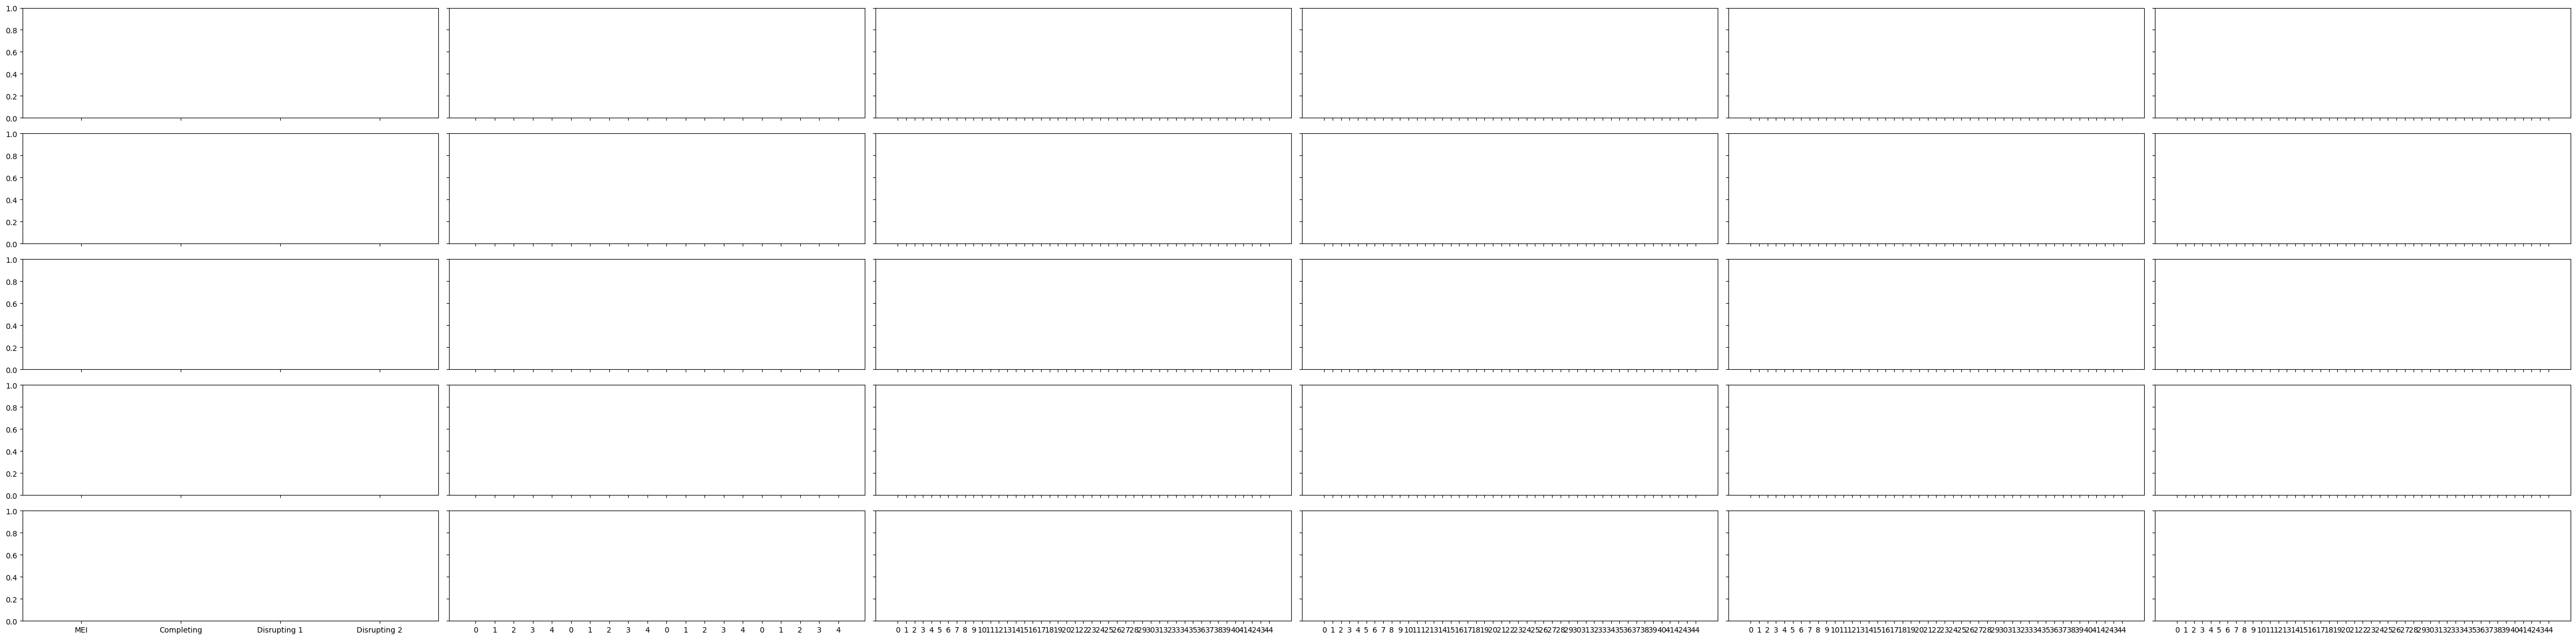

In [12]:
key_results = results.fetch(
    "config_id",
    as_dict=True,
)

for idx, result in enumerate(key_results):
    # highest_inh_1_config_id = key_results[0]["config_id"]
    # # '32645fb5a995f73c4aba131b1c598425'
    # # %%
    # highest_inh_1_results = (results & {"config_id": highest_inh_1_config_id}).fetch(
    #     download_path="/tmp", as_dict=True
    # )
    if idx > 0:
        break
    # with open(highest_inh_1_results[idx]["all_idata"], "rb") as f:
    #     all_idata = pickle.load(f)
    # print("config_id:", result["config_id"])
    result_data = (results & {"config_id": result["config_id"]}).fetch1()
    print(result_data)
    with open(result_data["all_idata"], "rb") as f:
        all_idata = pickle.load(f)
    # g_dim = highest_inh_1_results[idx]["g_dim"]
    g_dim = result_data["g_dim"]
    # disrupting_pattern_indices = highest_inh_1_results[idx]["disrupting_pattern_indices"]
    disrupting_pattern_indices = result_data["disrupting_pattern_indices"]
    (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    ) = plot_posterior_binary(g_dim, disrupting_pattern_indices, all_idata)

{'config_id': '170aca6956072ba57ed063b9abe956fa', 'seed': 42, 'g_dim': 5, 'g_prob': 0.4, 'i_sigma': 80.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': '170aca6956072ba57ed063b9abe956fa_idata.pkl', 'all_stimuli': '170aca6956072ba57ed063b9abe956fa_stimuli.pkl', 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}


/src/project/probcs/utils/plotting.py:791: RuntimeWarning: invalid value encountered in scalar divide
  perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100


{'config_id': '20fde9e170538ce2790824ad39d74fa0', 'seed': 42, 'g_dim': 5, 'g_prob': 0.5, 'i_sigma': 80.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': '20fde9e170538ce2790824ad39d74fa0_idata.pkl', 'all_stimuli': '20fde9e170538ce2790824ad39d74fa0_stimuli.pkl', 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}
{'config_id': '27a0b0901e0332d12bf74e9284fa3cee', 'seed': 42, 'g_dim': 5, 'g_prob': 0.6, 'i_sigma': 60.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': '27a0b0901e0332d12bf74e9284fa3cee_idata.pkl', 'all_stimuli': '27a0b0901e0332d12bf74e9284fa3cee_stimuli.pkl', 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}
{'config_id': '33eca61e553488112050ab7f445e21bf', 'seed': 42, 'g_dim': 5, 'g_prob': 0.5, 'i_sigma': 120.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': '33eca61e553488

/src/project/probcs/utils/plotting.py:791: RuntimeWarning: invalid value encountered in scalar divide
  perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100


{'config_id': '58dfed1f07841d0e7b073f591d6ed3b7', 'seed': 42, 'g_dim': 5, 'g_prob': 0.1, 'i_sigma': 100.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': '58dfed1f07841d0e7b073f591d6ed3b7_idata.pkl', 'all_stimuli': '58dfed1f07841d0e7b073f591d6ed3b7_stimuli.pkl', 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}


...

/src/project/probcs/utils/plotting.py:791: RuntimeWarning: invalid value encountered in scalar divide
  perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100


{'config_id': 'fdc37c608e99f69c696afecc0663612b', 'seed': 42, 'g_dim': 5, 'g_prob': 0.6, 'i_sigma': 100.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': 'fdc37c608e99f69c696afecc0663612b_idata.pkl', 'all_stimuli': 'fdc37c608e99f69c696afecc0663612b_stimuli.pkl', 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}
{'config_id': 'ffcceda29eddb0fb9214cff7a53d7b5f', 'seed': 42, 'g_dim': 5, 'g_prob': 0.4, 'i_sigma': 100.0, 'patterns_offset': 0.0, 'image_type': 'exc', 'n_tune': 600, 'n_draws': 600, 'n_chains': 4, 'n_cores': 4, 'all_idata': 'ffcceda29eddb0fb9214cff7a53d7b5f_idata.pkl', 'all_stimuli': 'ffcceda29eddb0fb9214cff7a53d7b5f_stimuli.pkl', 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}


/src/project/probcs/utils/plotting.py:791: RuntimeWarning: invalid value encountered in scalar divide
  perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100


Error in callback <function _draw_all_if_interactive at 0x7efc47a77a60> (for post_execute):


KeyboardInterrupt: 

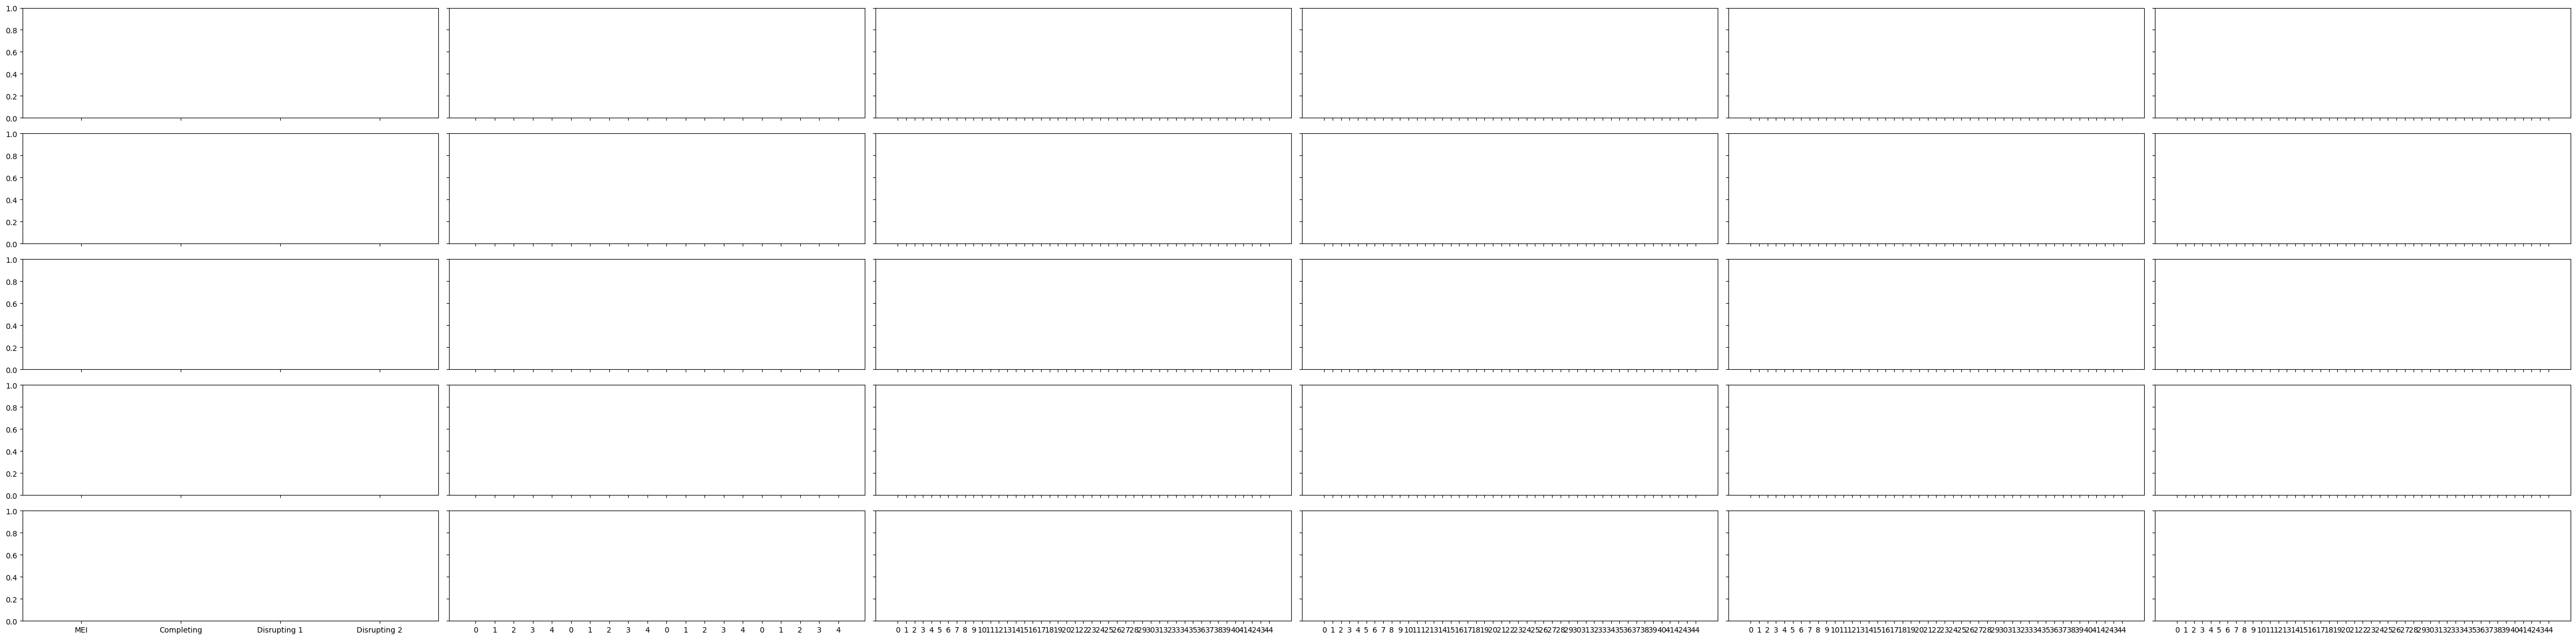

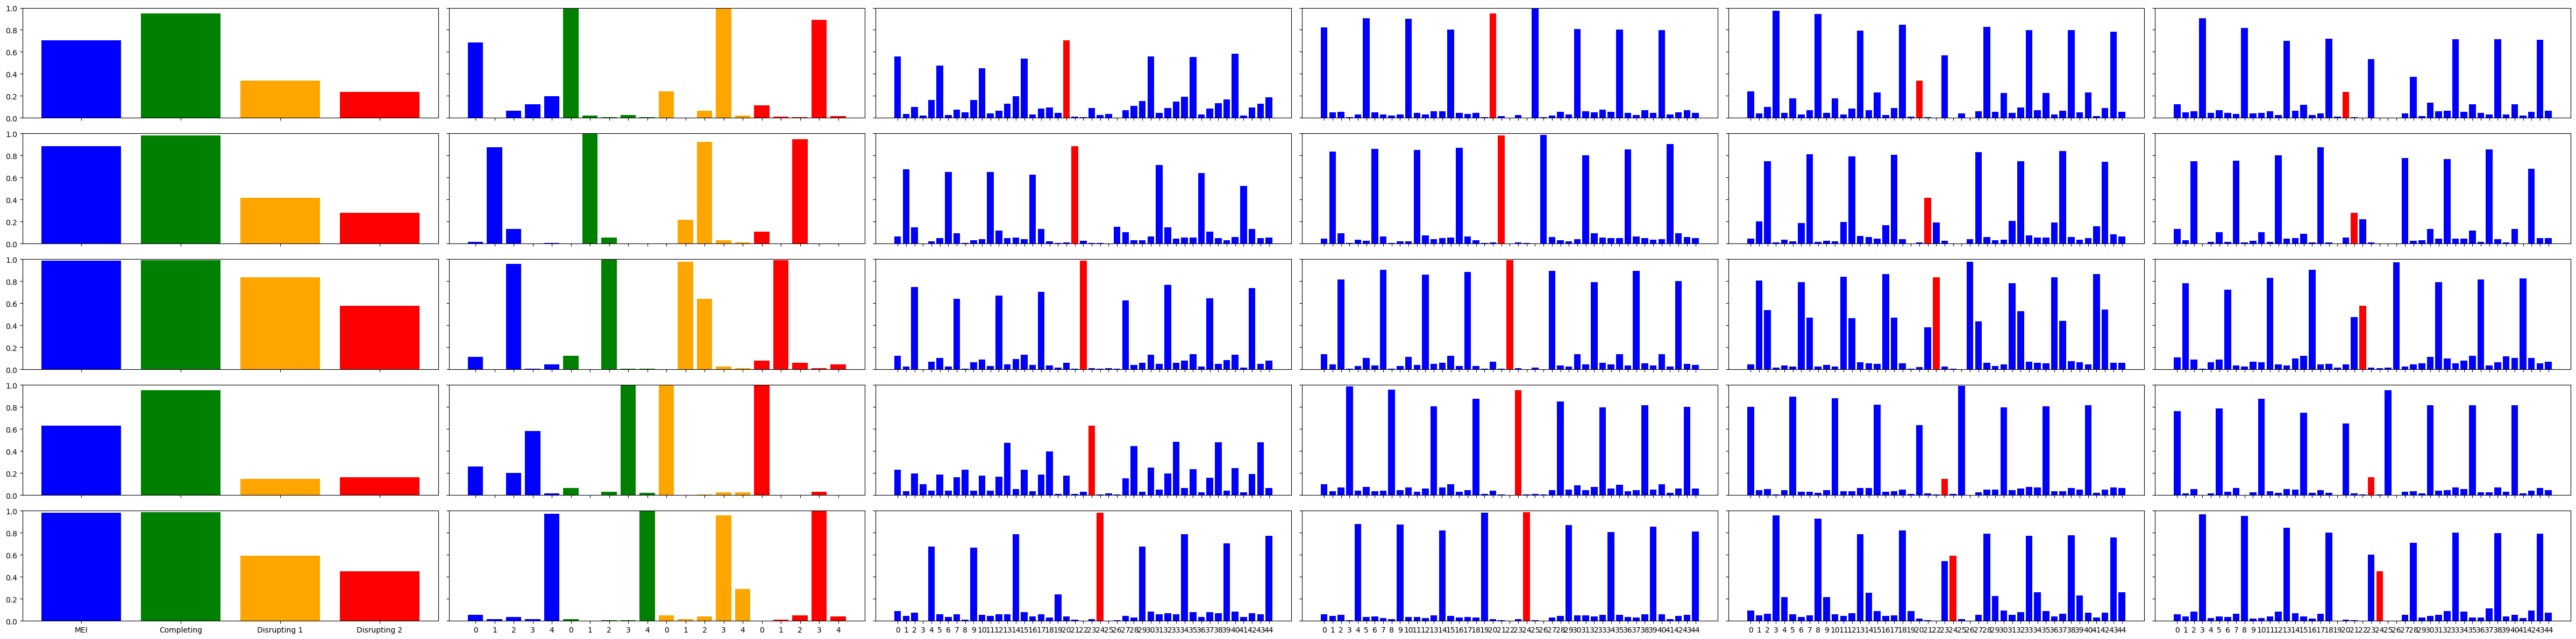

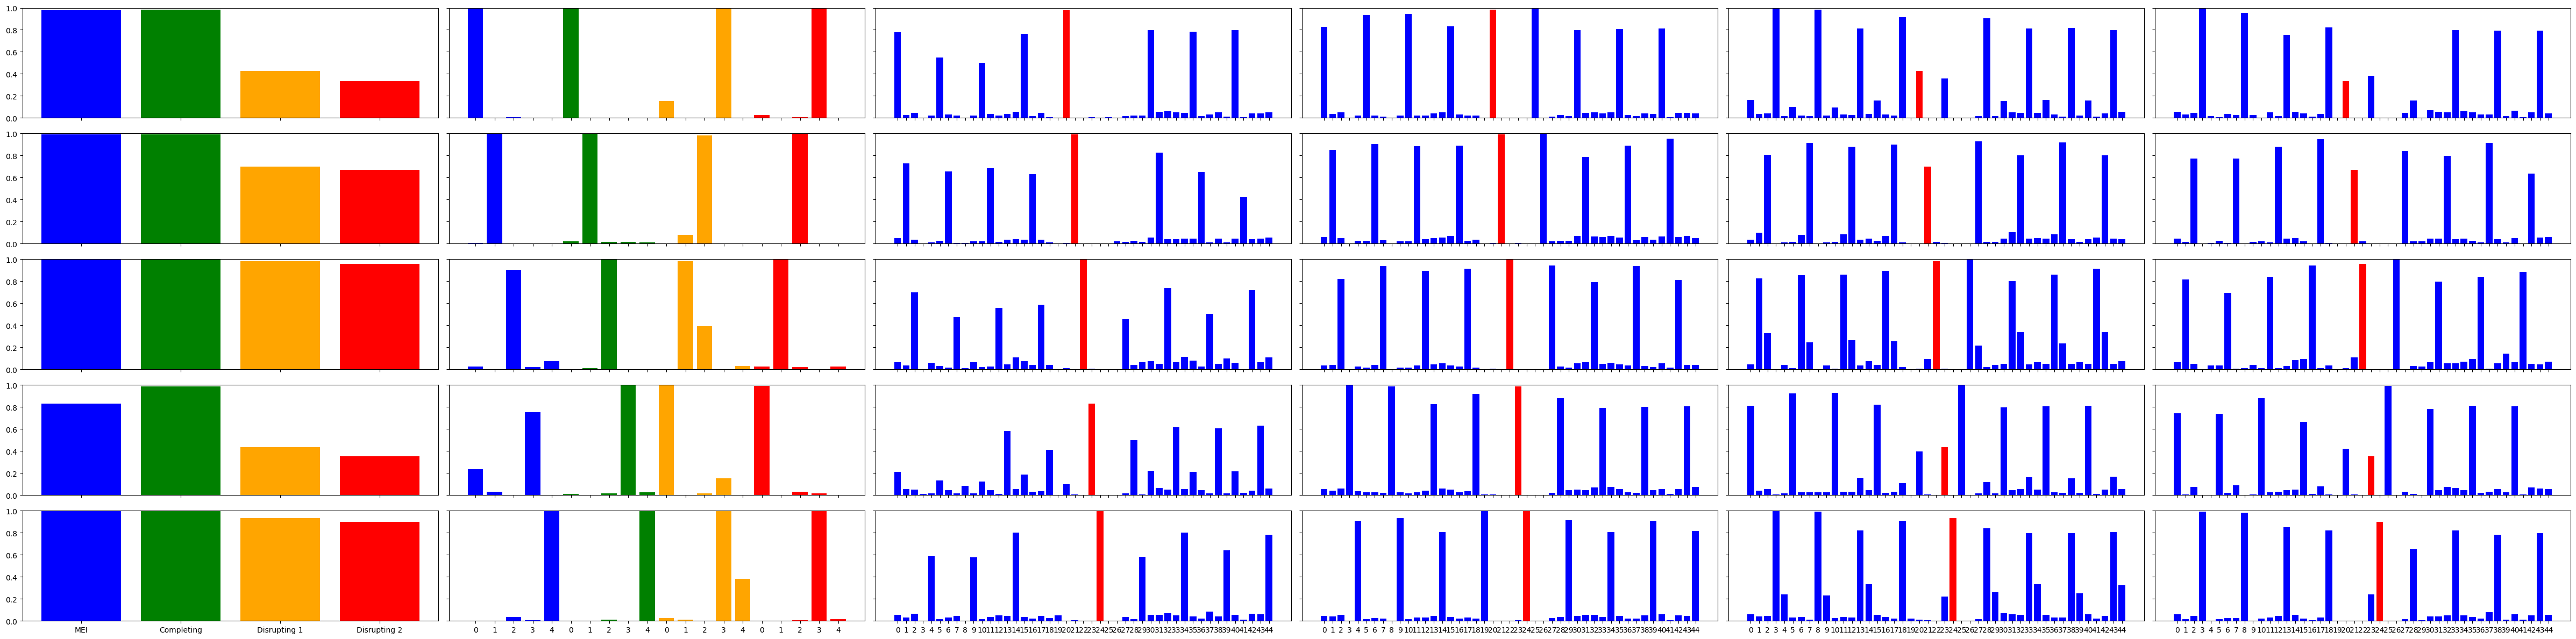

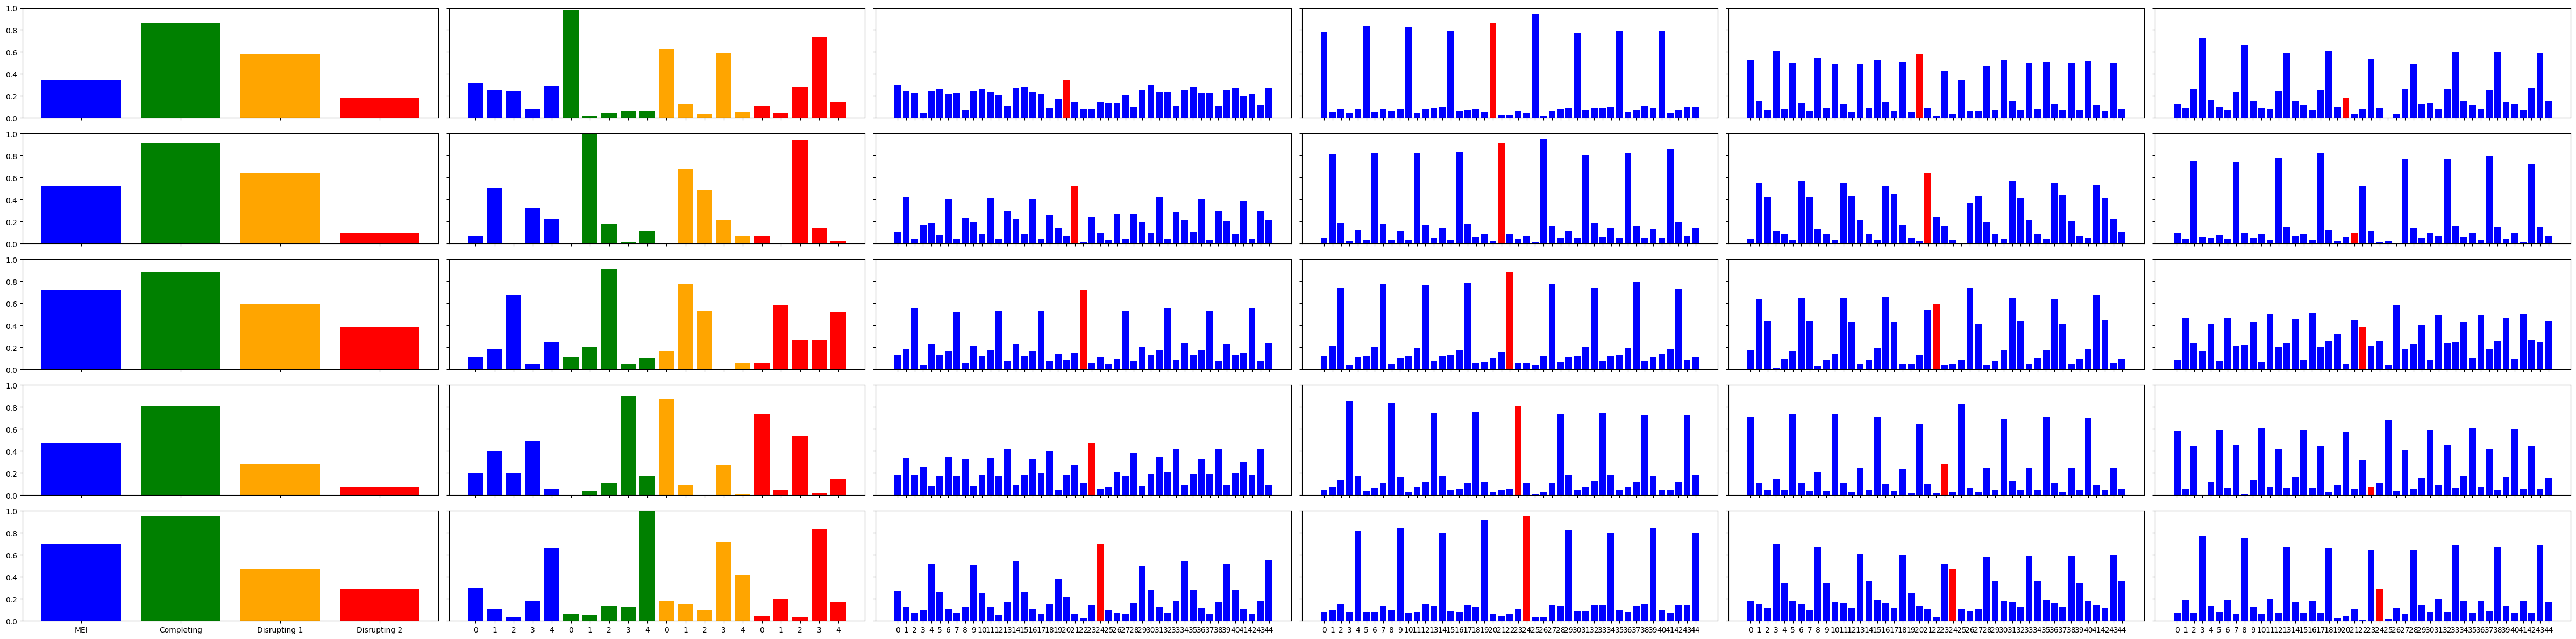

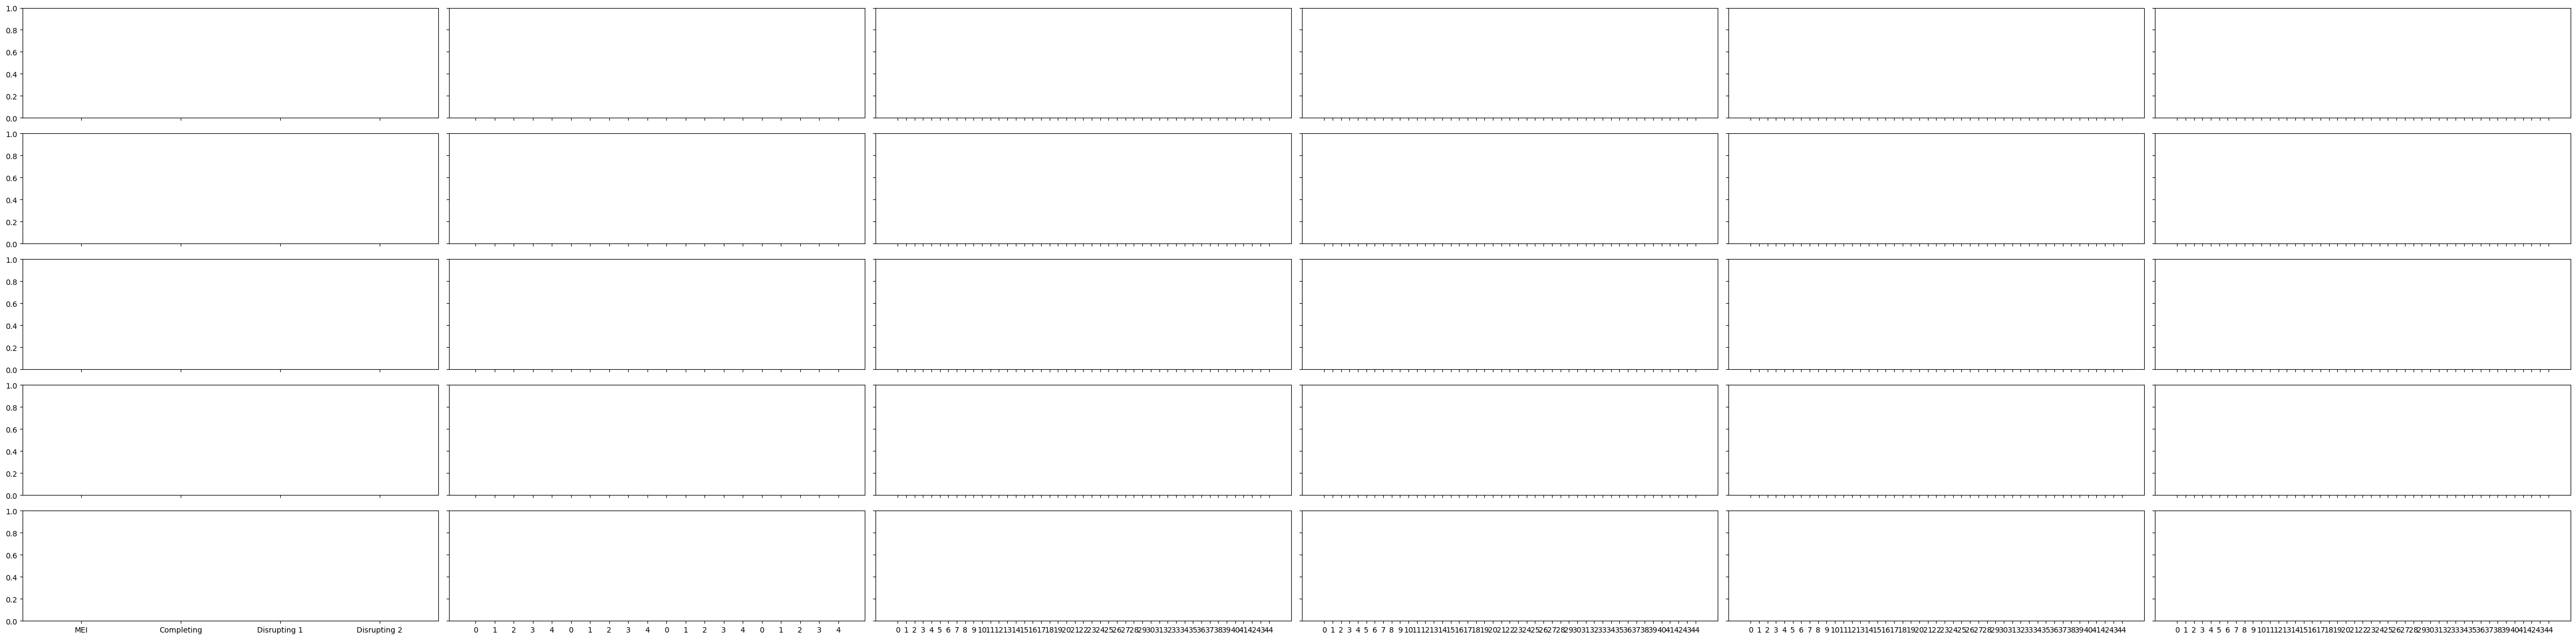

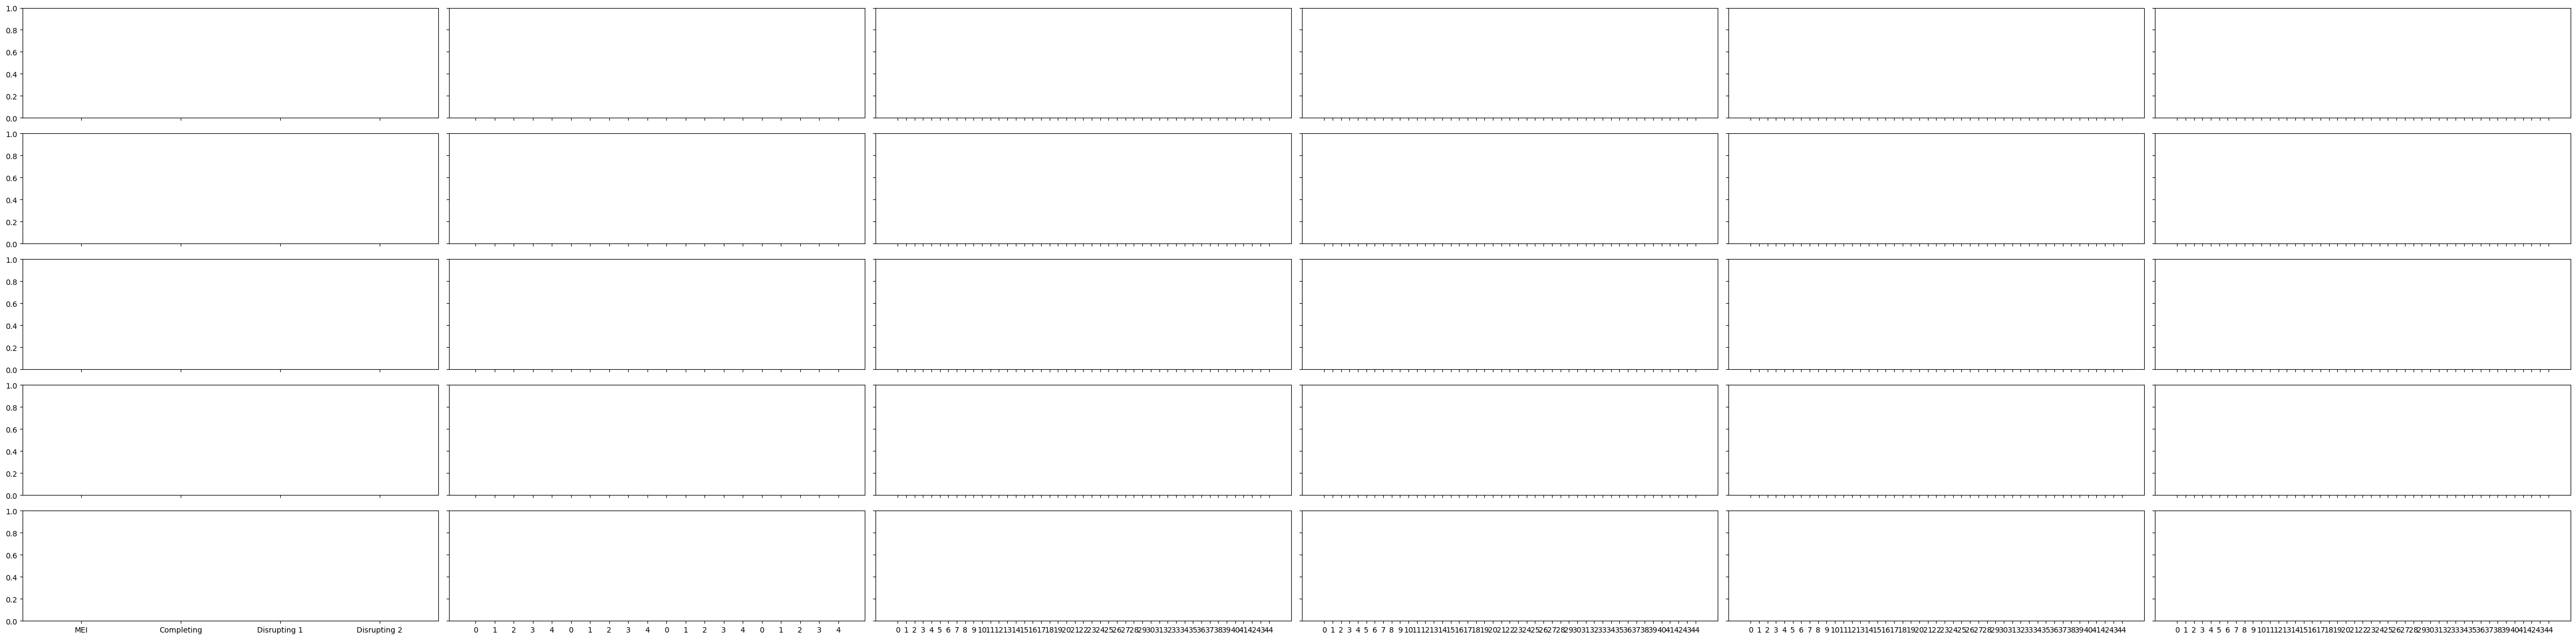

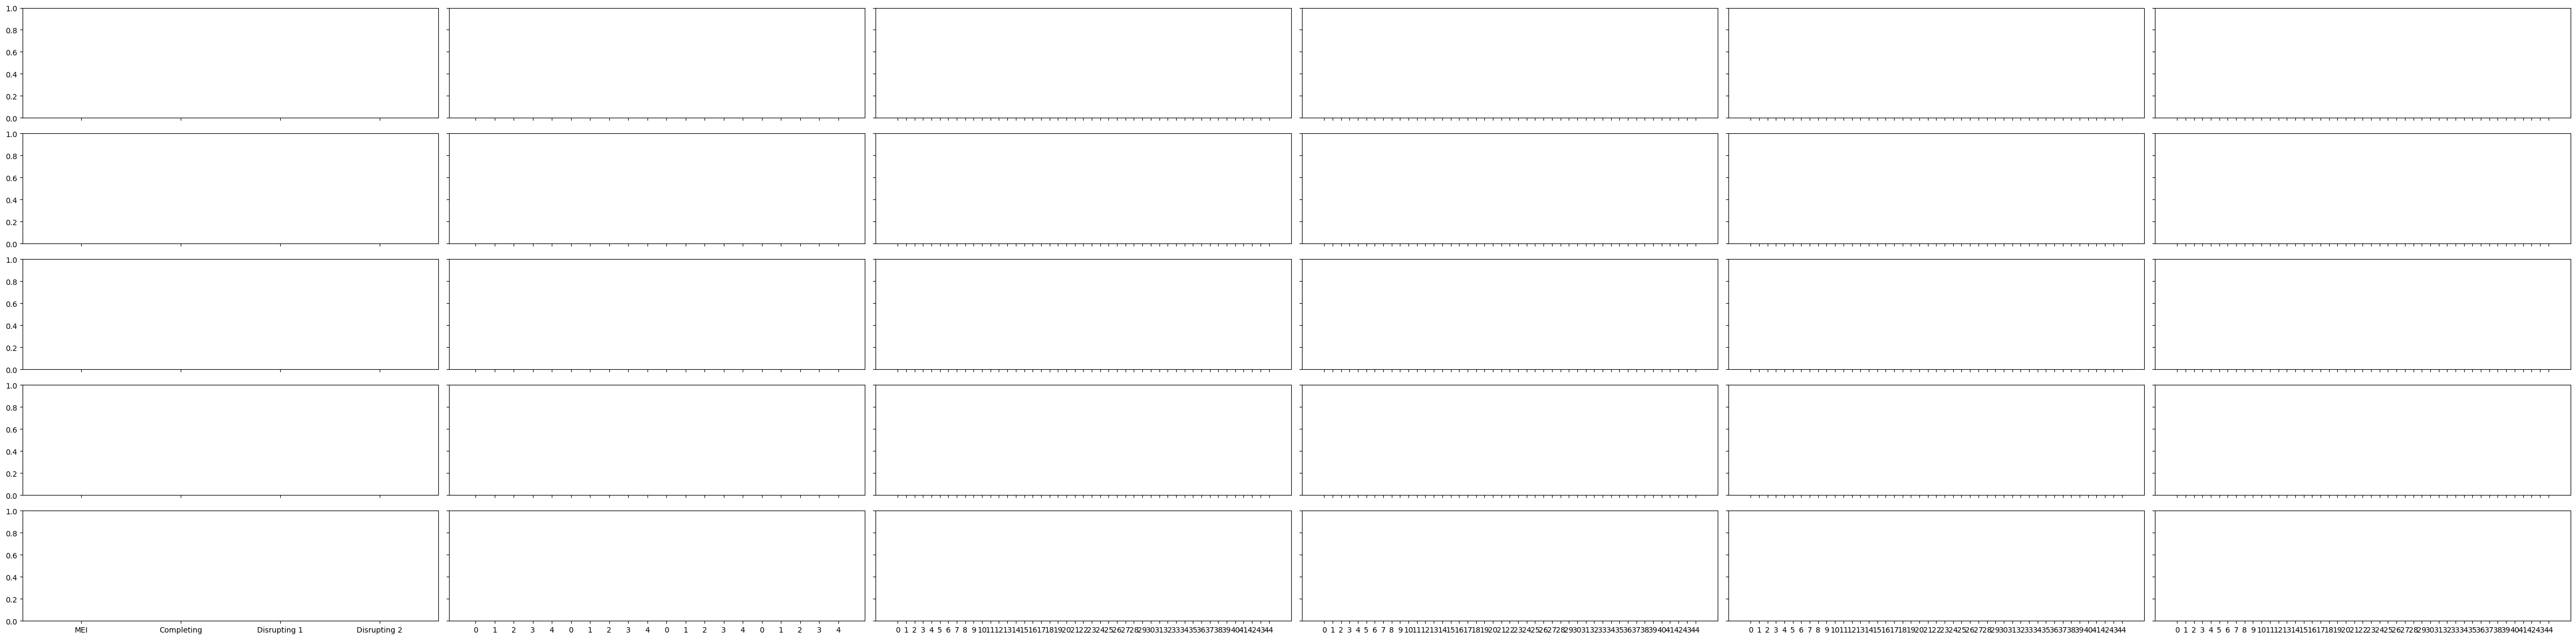

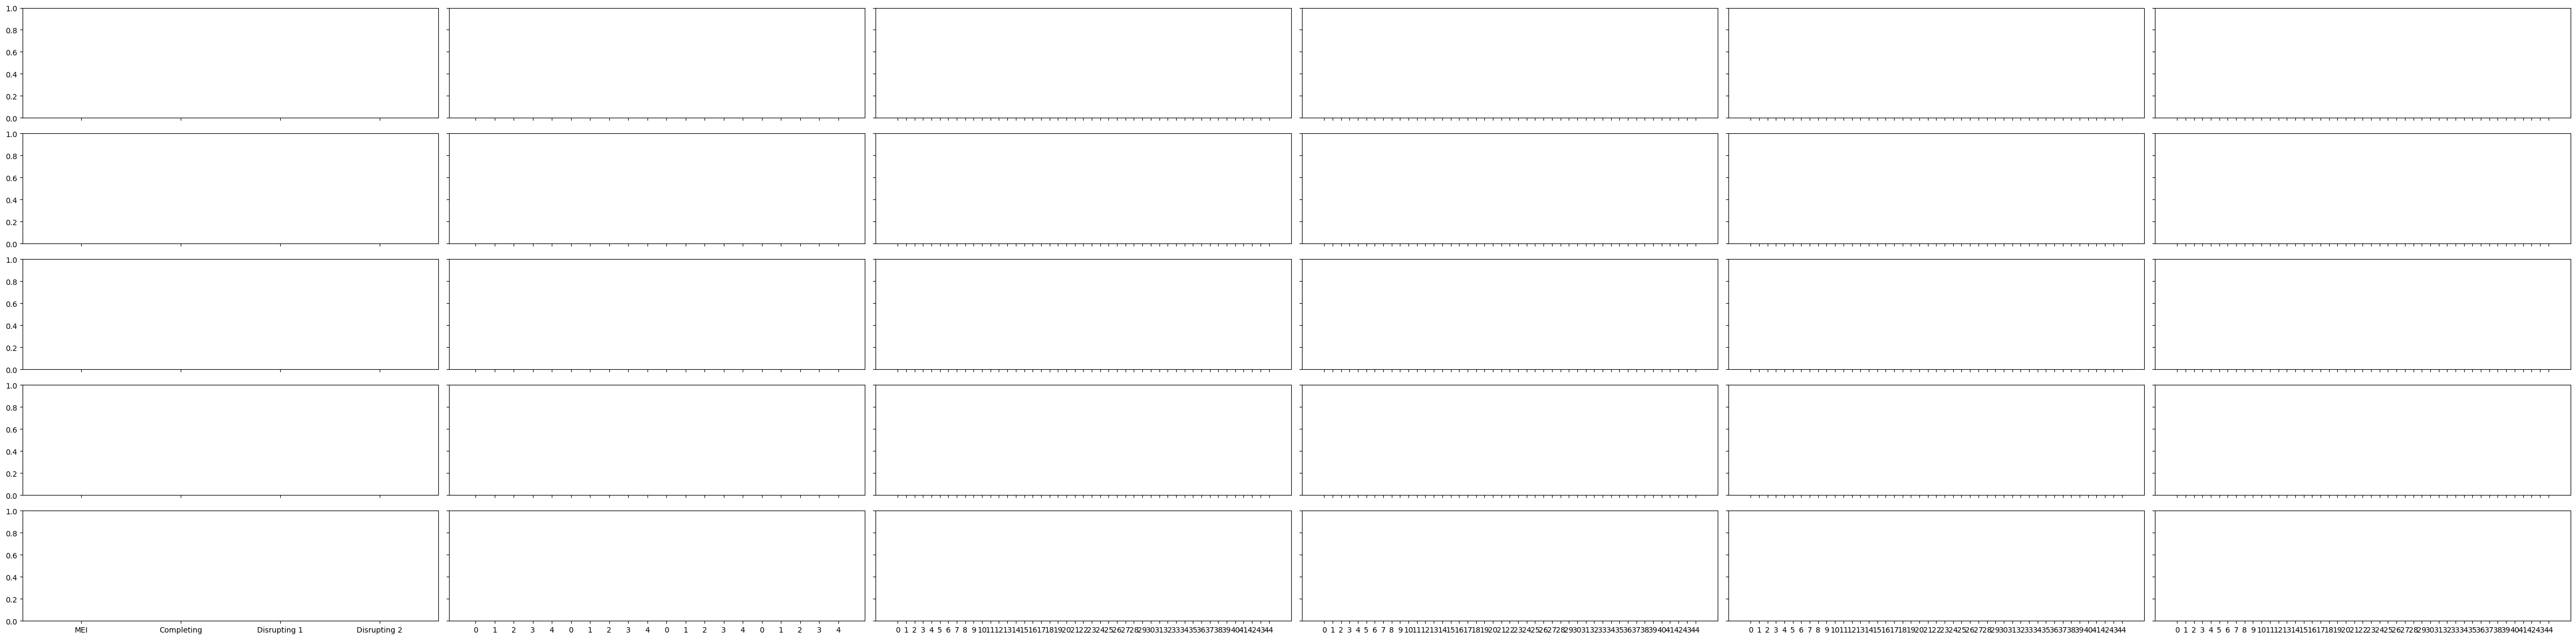

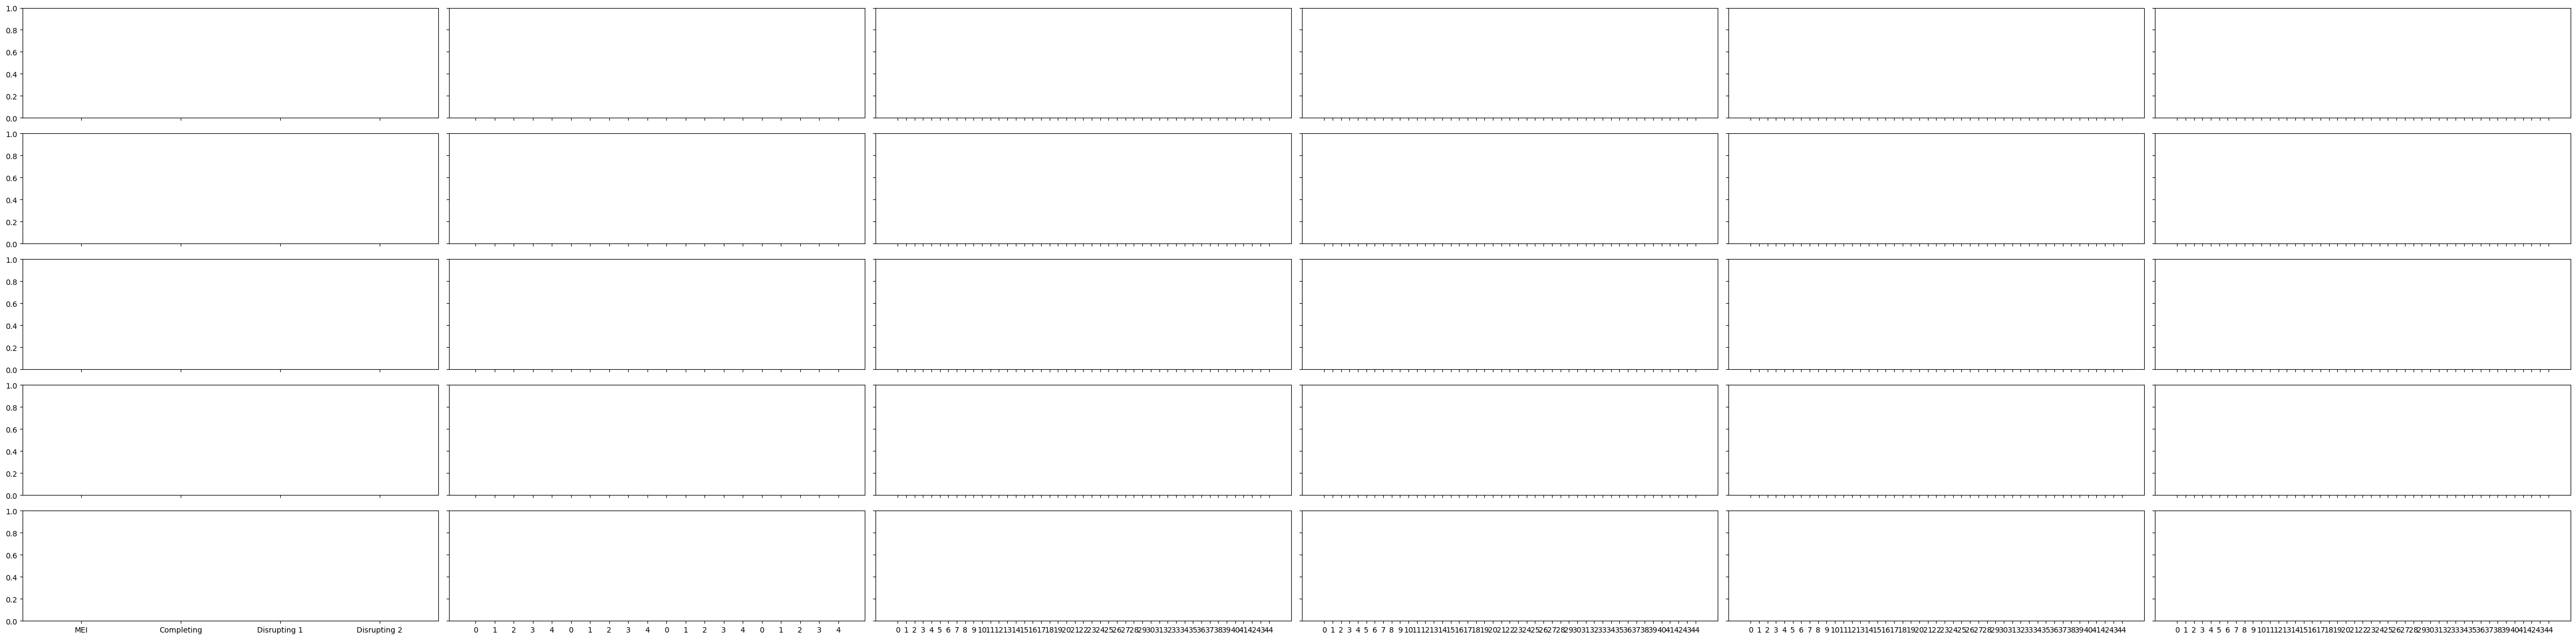

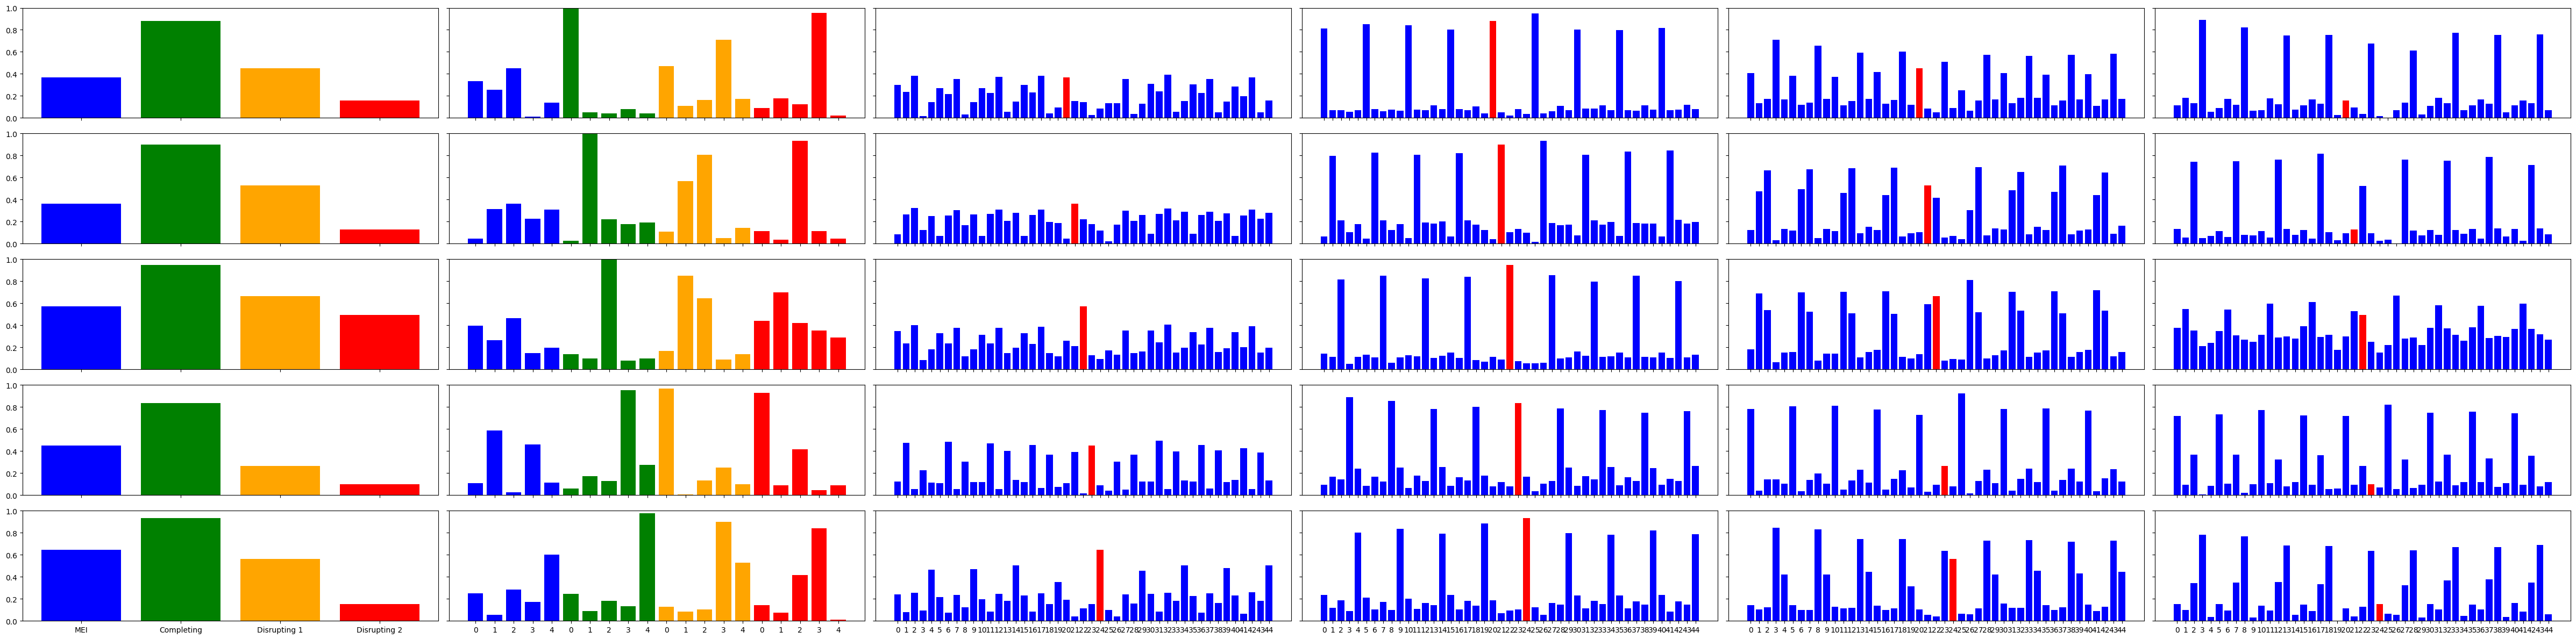

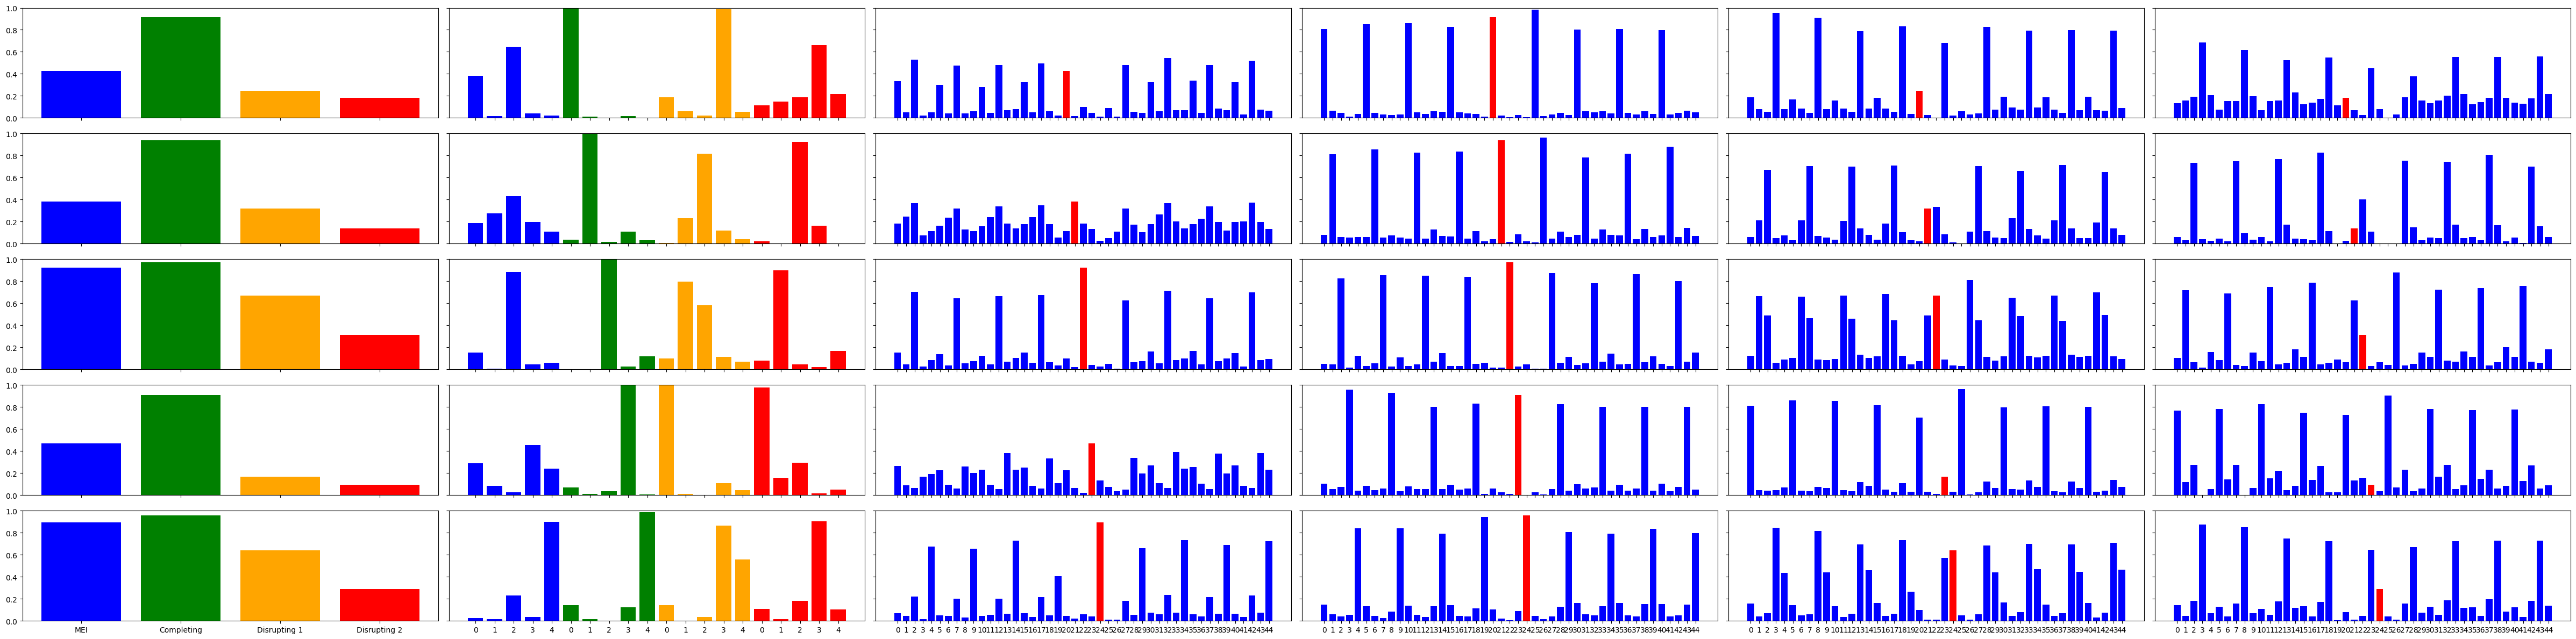

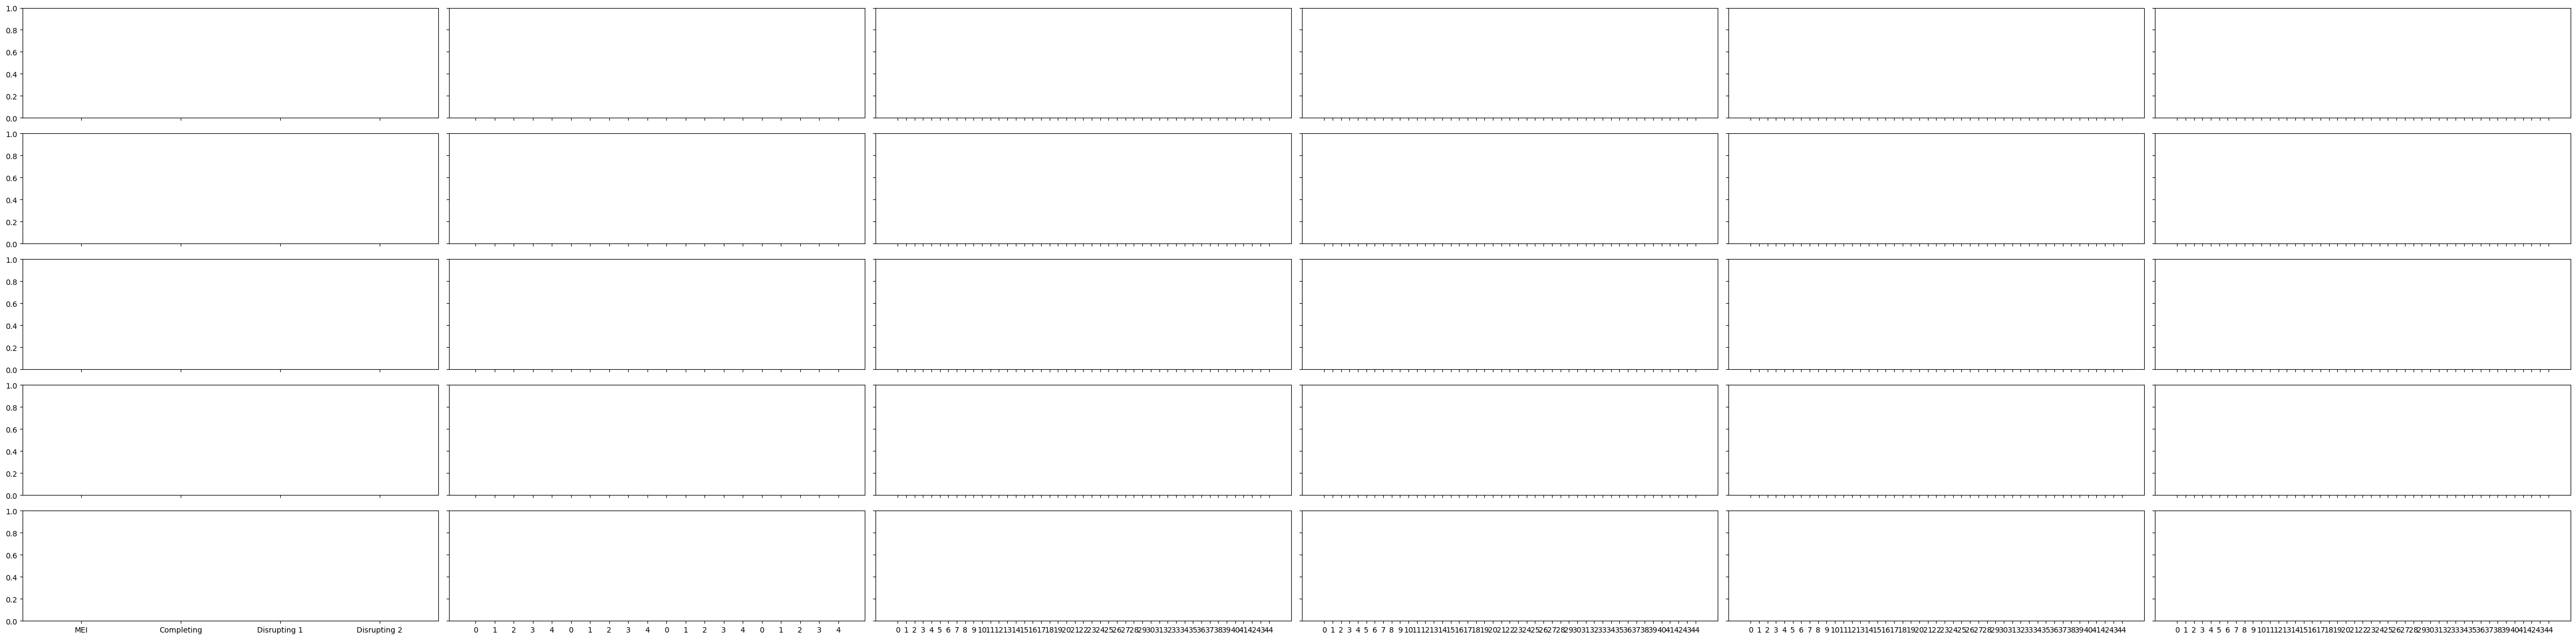

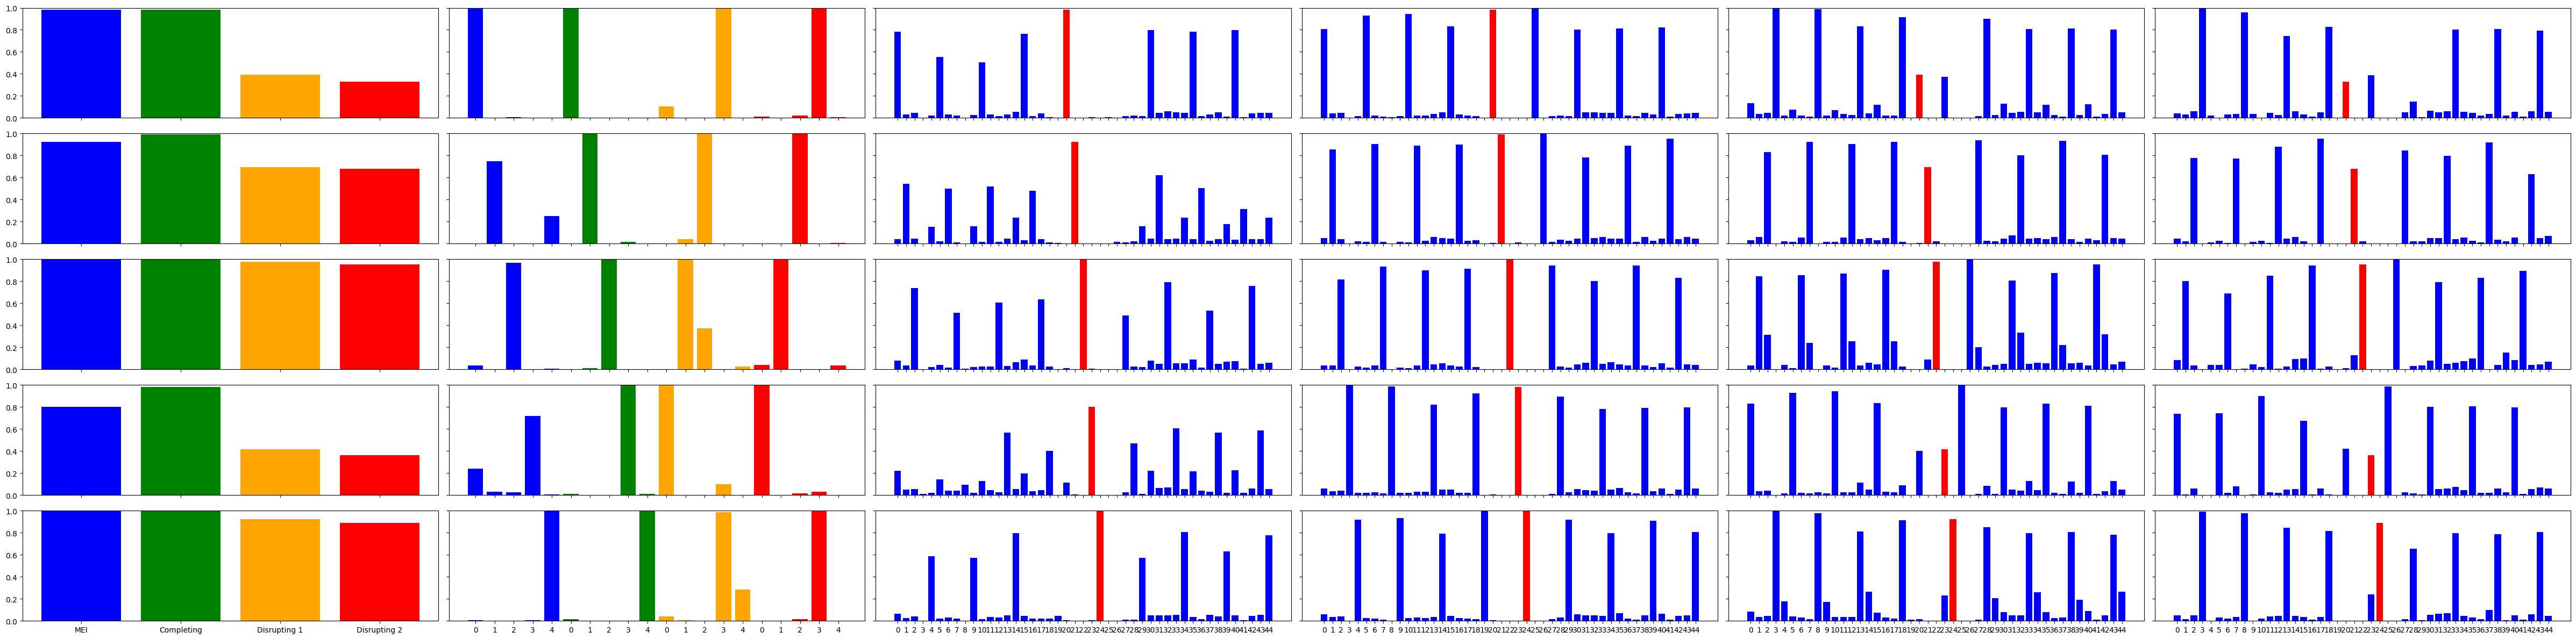

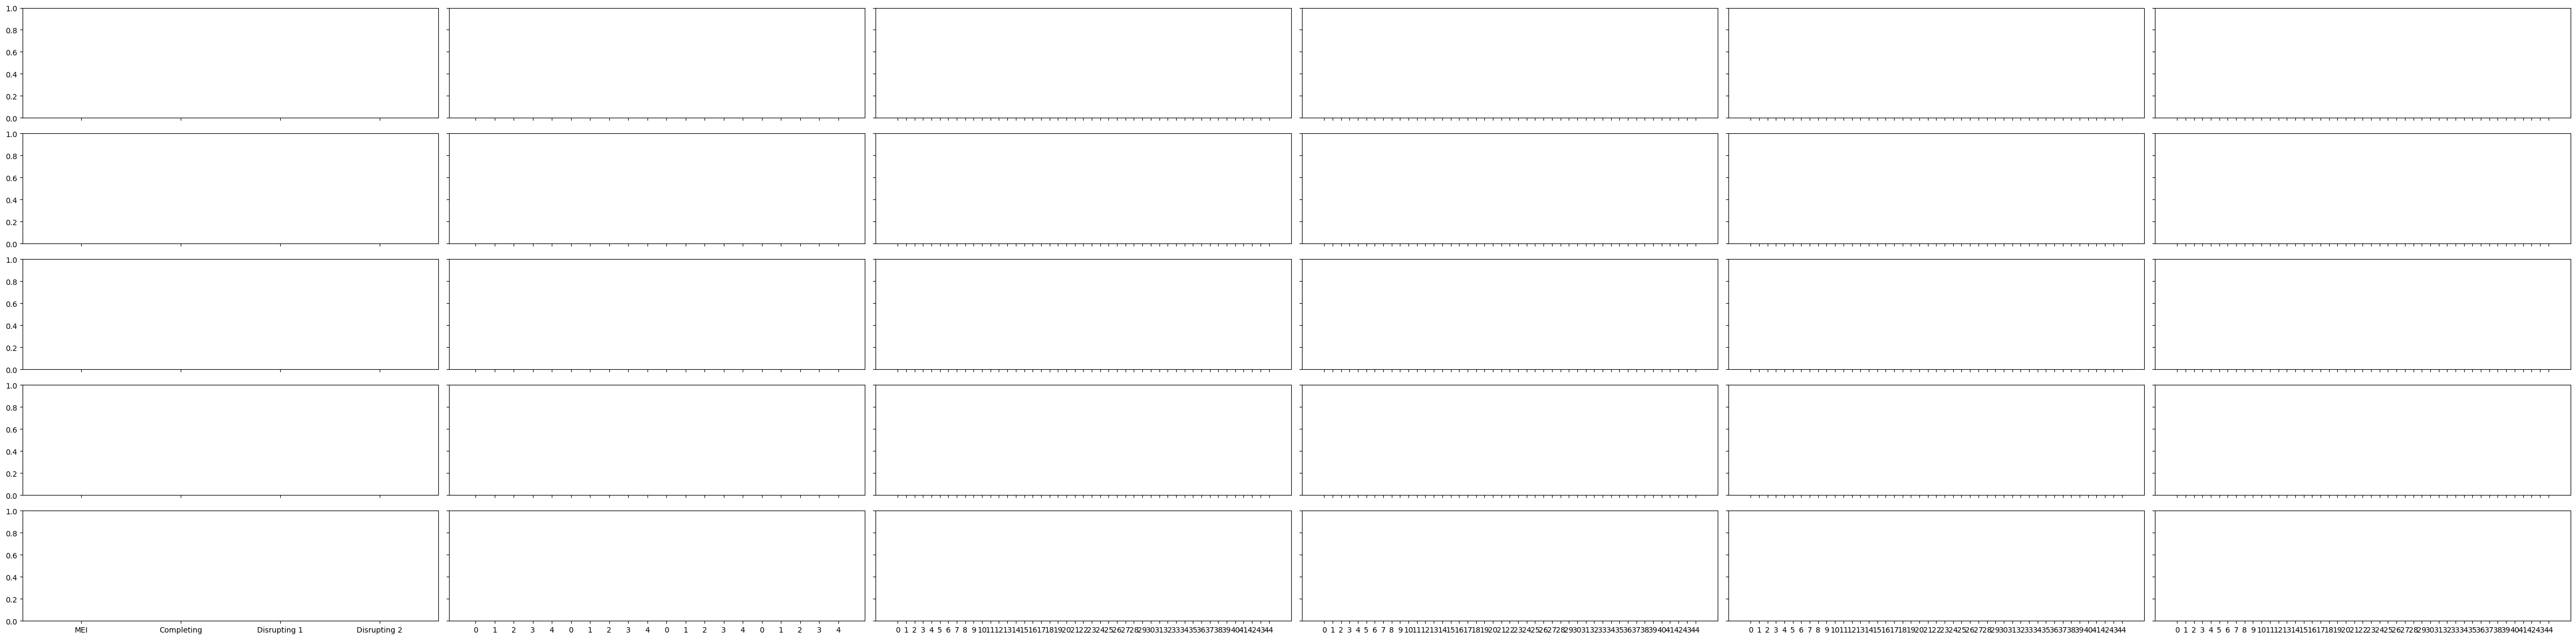

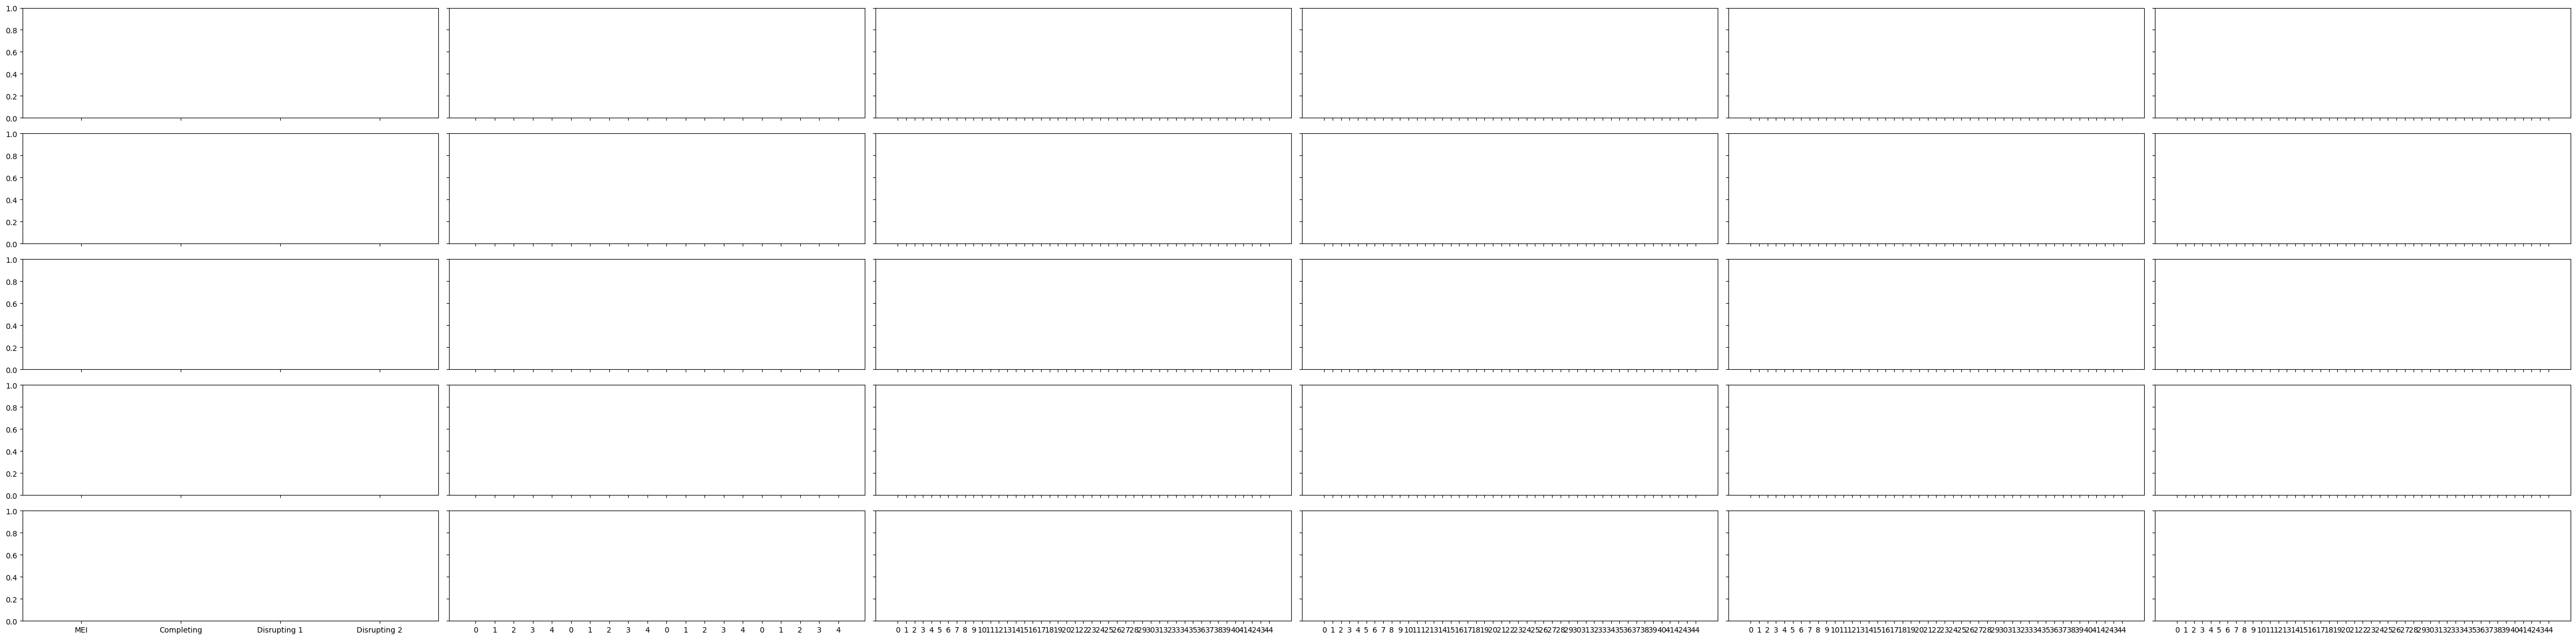

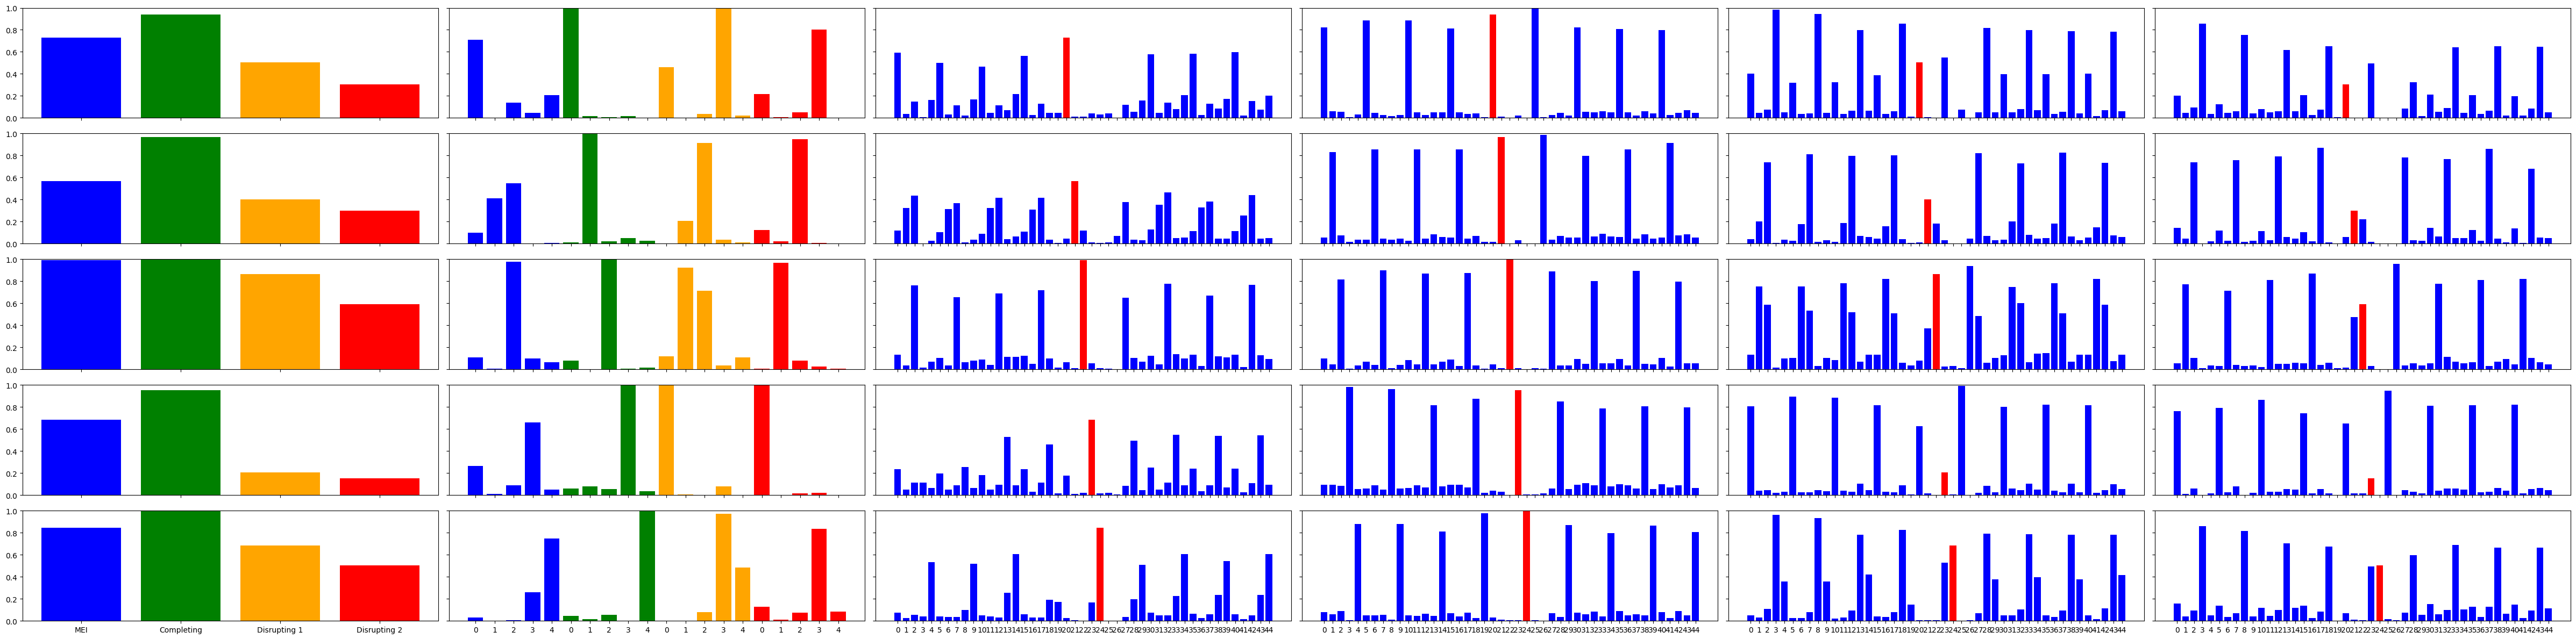

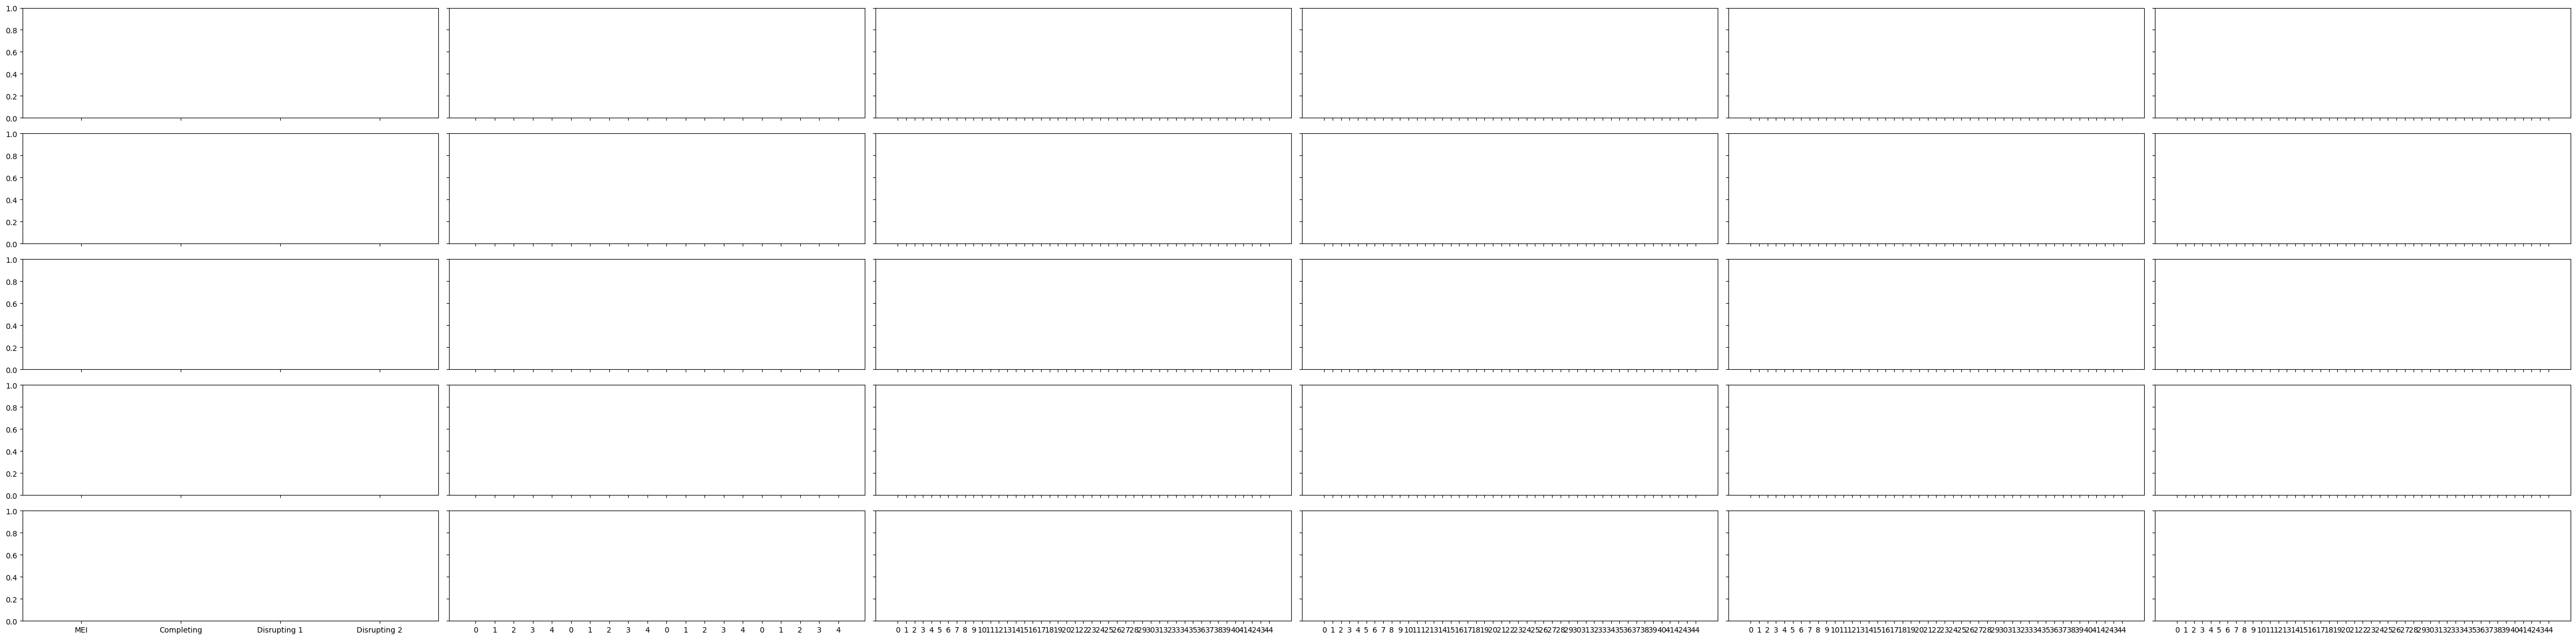

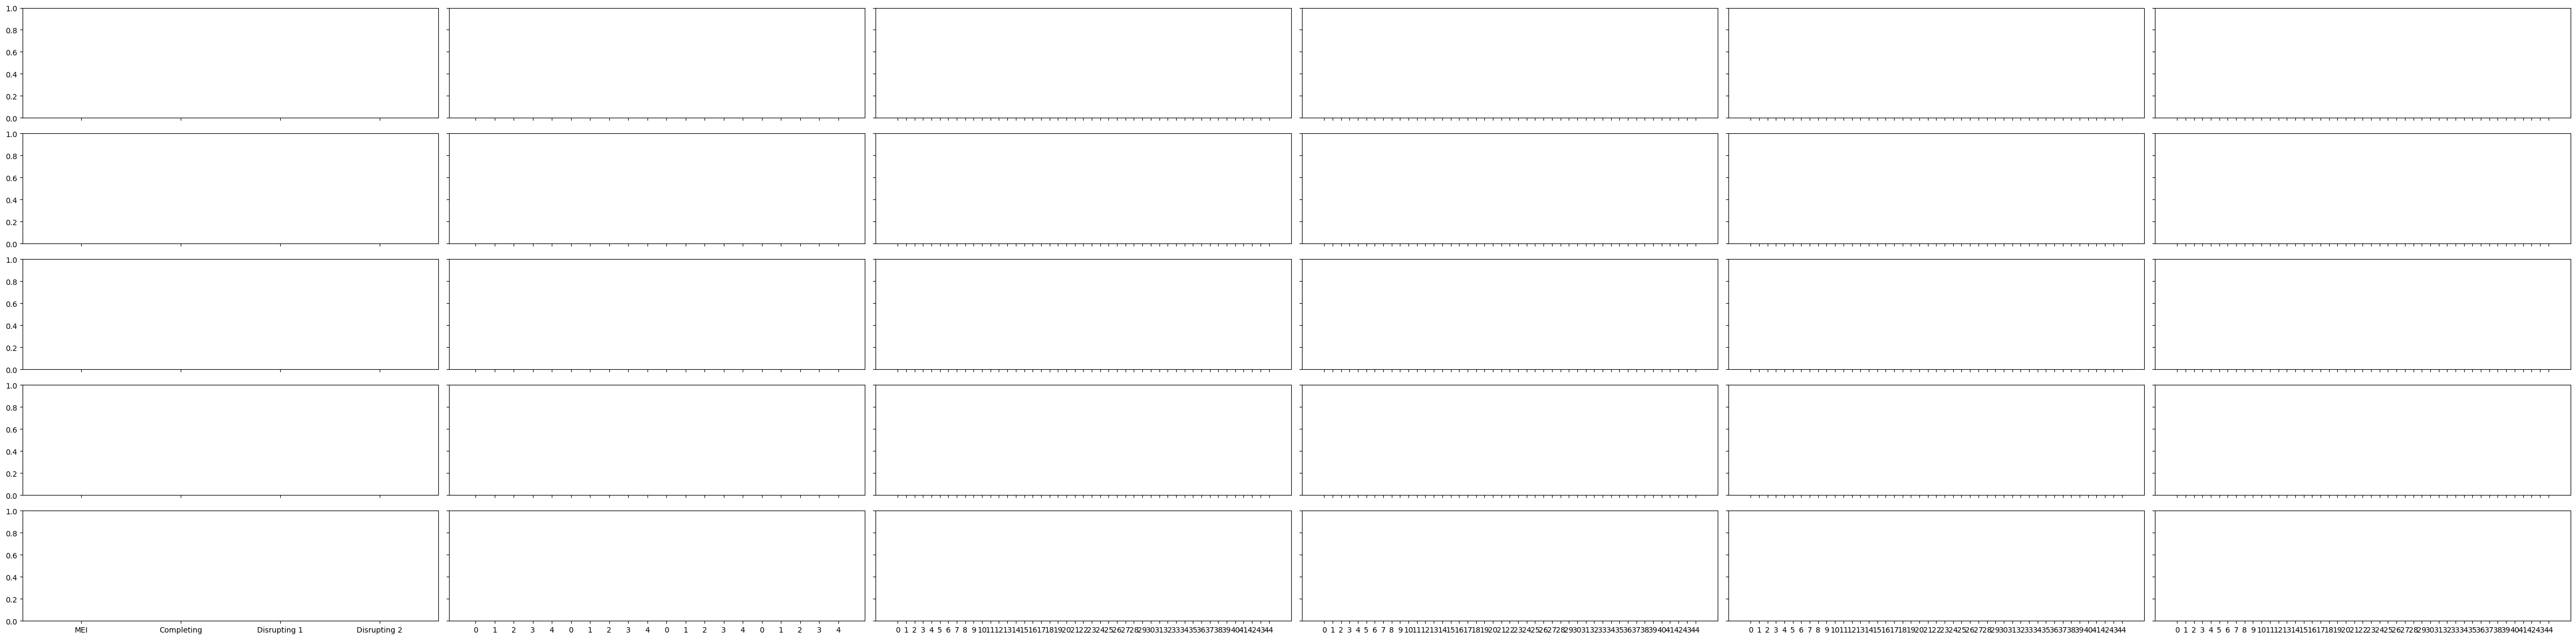

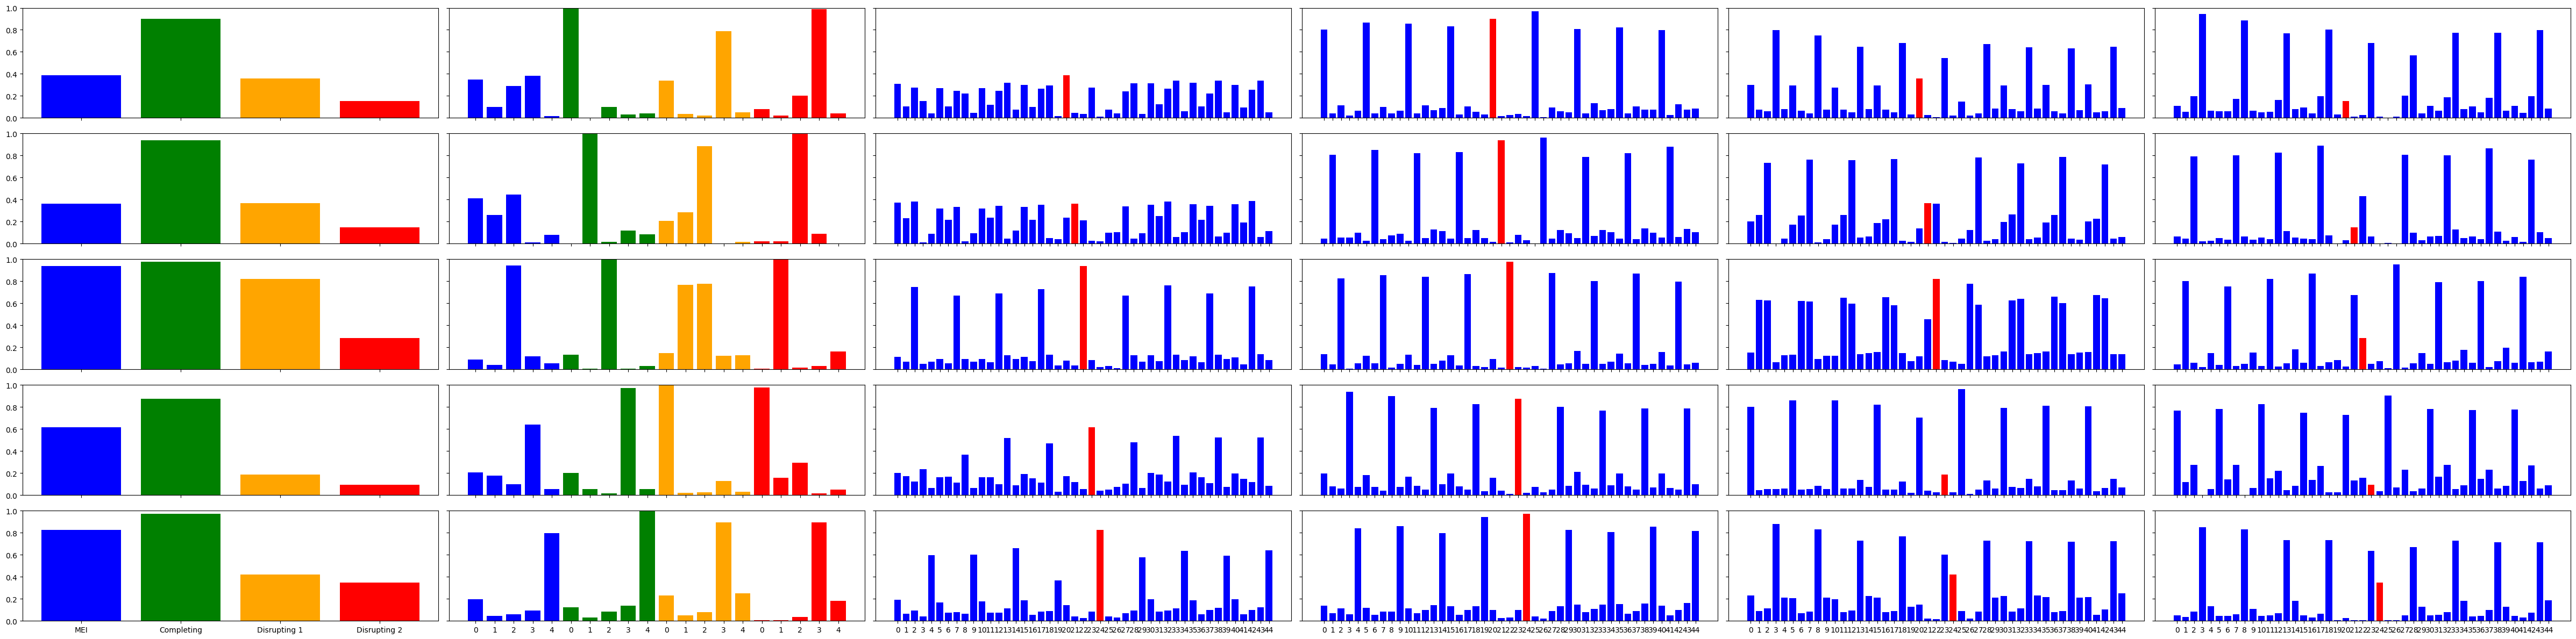

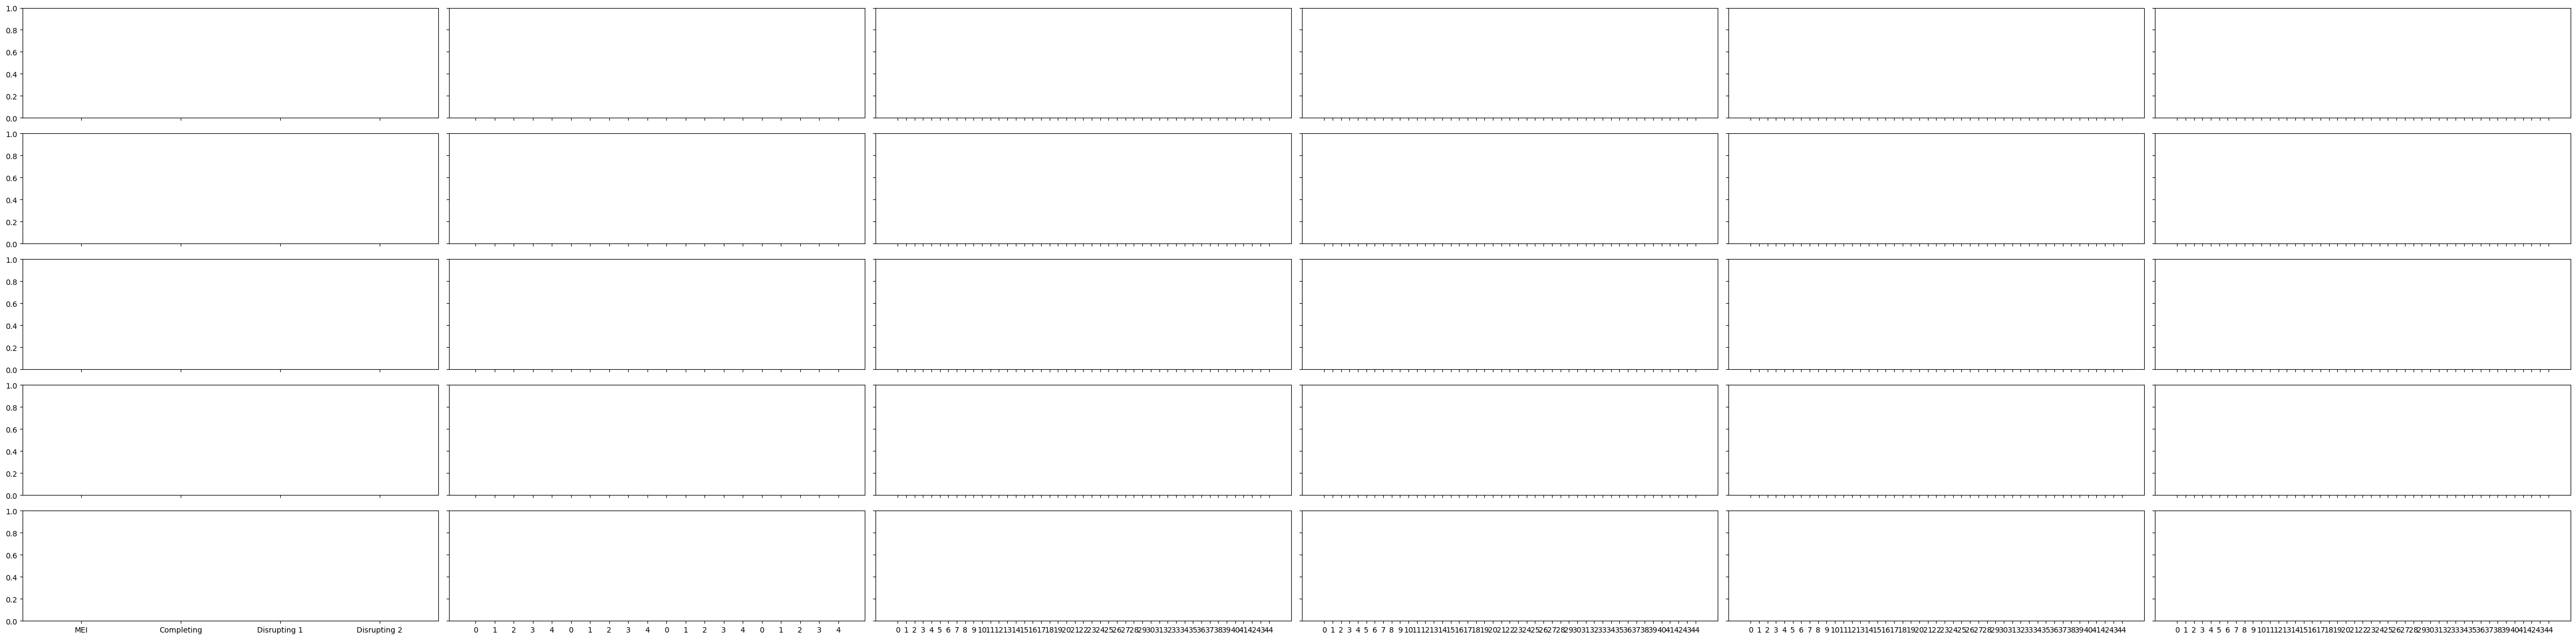

In [13]:
key_results = results.fetch(
    "config_id",
    as_dict=True,
)

for idx, result in enumerate(key_results):
    # highest_inh_1_config_id = key_results[0]["config_id"]
    # # '32645fb5a995f73c4aba131b1c598425'
    # # %%
    # highest_inh_1_results = (results & {"config_id": highest_inh_1_config_id}).fetch(
    #     download_path="/tmp", as_dict=True
    # )
    # if idx > 0:
    #     break
    # with open(highest_inh_1_results[idx]["all_idata"], "rb") as f:
    #     all_idata = pickle.load(f)
    # print("config_id:", result["config_id"])
    result_data = (results & {"config_id": result["config_id"]}).fetch1()
    print(result_data)
    with open(result_data["all_idata"], "rb") as f:
        all_idata = pickle.load(f)
    # g_dim = highest_inh_1_results[idx]["g_dim"]
    g_dim = result_data["g_dim"]
    # disrupting_pattern_indices = highest_inh_1_results[idx]["disrupting_pattern_indices"]
    disrupting_pattern_indices = result_data["disrupting_pattern_indices"]
    (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    ) = plot_posterior_binary(g_dim, disrupting_pattern_indices, all_idata)